In [ ]:
import pandas as pd
import numpy as np

Load all data

In [ ]:
df = pd.read_csv('original_files/lucas_harmo_uf.csv') # LUCAS harmonized from: 10.1038/s41597-020-00675-z
df_2018_europe_topsoil = pd.read_csv('original_files//LUCAS-SOIL-2018.csv')
df_2015_europe_topsoil = pd.read_csv('original_files/LUCAS_Topsoil_2015_20200323.csv')
df_2012_romania_topsoil = pd.read_csv('original_files/Romania.csv')
df_2012_bulgaria_topsoil = pd.read_csv('original_files/Bulgaria.csv')
df_2009_europe_topsoil = pd.read_excel('original_files/LUCAS_TOPSOIL_v1.xlsx')
df_MAOC = pd.read_csv('original_files/LCS.csv')
df_microbial = pd.read_csv('original_files/microbialProperties_SOC_data.csv')
df_BD = pd.read_csv('original_files/BulkDensity_2018_final-2.csv')
df_2015_ancilliary = pd.read_csv('original_files/LUCAS2015_AncillaryData_20201007.csv')

import pyreadr
result = pyreadr.read_r('original_files/Boundary_df_th_coords.rds')
df_MAOCHS = result[None]

Select desired columns for each

In [ ]:
def select_columns(df, columns_to_keep):
    return df[columns_to_keep]
df = select_columns(df, ['point_id', 'year', 'gps_lat', 'gps_ew', 'gps_long', 'lc1', 'lc1_label', 'survey_date'])
df_2018_europe_topsoil = select_columns(df_2018_europe_topsoil, ['POINTID', 'pH_CaCl2', 'OC', 'CaCO3', 'P', 'N', 'K', 'Ox_Al', 'Ox_Fe'])
df_2015_europe_topsoil = select_columns(df_2015_europe_topsoil, ['Point_ID', 'Coarse', 'Clay', 'Sand', 'Silt', 'pH(CaCl2)', 'OC', 'CaCO3', 'P', 'N', 'K'])
df_2012_romania_topsoil = select_columns(df_2012_romania_topsoil, ['POINTID', 'coarse', 'clay', 'silt', 'sand', 'pHinCaCl2', 'OC', 'CaCO3', 'N', 'P', 'K'])
df_2012_bulgaria_topsoil = select_columns(df_2012_bulgaria_topsoil, ['POINT_ID', 'coarse', 'clay', 'silt', 'sand', 'pHinCaCl2', 'OC', 'CaCO3', 'N', 'P', 'K'])
df_2009_europe_topsoil = select_columns(df_2009_europe_topsoil, ['POINT_ID', 'coarse', 'clay', 'silt', 'sand', 'pH_in_CaCl2', 'OC', 'CaCO3', 'N', 'P', 'K'])
df_BD = select_columns(df_BD, ['POINT_ID', 'BD 0-20'])
df_MAOC = select_columns(df_MAOC, ['POINT_ID', 'OC_pom_g_kg', 'OC_sc_g_kg'])
df_MAOCHS = select_columns(df_MAOCHS, ['POINT_ID', 'OC_pom_g_kg', 'OC_sc_g_kg'])
df_microbial = select_columns(df_microbial, ['LUCAS_ID', 'Cmic'])
df_2015_ancilliary = select_columns(df_2015_ancilliary, ['POI', 'Soil_Group'])

Rename columns

In [ ]:
df = df.rename(columns={'point_id': 'POINT_ID'})
df_2018_europe_topsoil = df_2018_europe_topsoil.rename(columns={'POINTID': 'POINT_ID'})
df_2015_europe_topsoil = df_2015_europe_topsoil.rename(columns={'Point_ID': 'POINT_ID', 'pH(CaCl2)': 'pH_CaCl2', 'pH(H2O)': 'pH_H2O'})
df_2012_romania_topsoil = df_2012_romania_topsoil.rename(columns={'POINTID': 'POINT_ID', 'coarse': 'Coarse', 'clay': 'Clay', 'silt': 'Silt', 'sand': 'Sand', 'pHinH2O': 'pH_H2O', 'pHinCaCl2': 'pH_CaCl2'})
df_2012_bulgaria_topsoil = df_2012_bulgaria_topsoil.rename(columns={'coarse': 'Coarse', 'clay': 'Clay', 'silt': 'Silt', 'sand': 'Sand', 'pHinH2O': 'pH_H2O', 'pHinCaCl2': 'pH_CaCl2'})
df_2009_europe_topsoil = df_2009_europe_topsoil.rename(columns={'coarse': 'Coarse', 'clay': 'Clay', 'silt': 'Silt', 'sand': 'Sand', 'pH_in_H2O': 'pH_H2O', 'pH_in_CaCl2': 'pH_CaCl2','sample_ID': 'SoilID'})
df_microbial = df_microbial.rename(columns={'LUCAS_ID': 'POINT_ID'})
df_MAOCHS = df_MAOCHS.rename(columns={col: col + '_HS' for col in ['OC_fractions', 'OC_pom_g_kg', 'OC_sc_g_kg', 'cluster_sse']})
df_2015_ancilliary = df_2015_ancilliary.rename(columns={'POI': 'POINT_ID'})

Integrate East-West (ew) into GPS

In [ ]:
df.loc[df['gps_ew'] == 'West', 'gps_long'] *= -1

Add year to sub datasets

In [ ]:
df_2018_europe_topsoil['year'] = 2018
df_2015_europe_topsoil['year'] = 2015
df_2012_romania_topsoil['year'] = 2012
df_2012_bulgaria_topsoil['year'] = 2012
df_2009_europe_topsoil['year'] = 2009
df_BD['year'] = 2018
df_MAOC['year'] = 2009
df_MAOCHS['year'] = 2009
df_microbial['year'] = 2018
df_2015_ancilliary['year'] = 2015

Make:
- strings to float (if possible)
- to 0.0 (if string indicates that)

In [ ]:
# if there are whitespac in the column, it is read by pd_read_csv as a string 
# -> function corrects that (if there are values below limit of determination, they are replaced with 0.0)
def string_to_float(df, column):
    df[column] = df[column].astype(str).str.strip().replace({'': None}) # make column entirely string, remove useless white space, make empty to None
    df[column] = pd.to_numeric(df[column], errors='coerce').fillna(0.0) # make column entirely numeric, if impossible to 0.0

for column in ['OC', 'CaCO3', 'P', 'N', 'K']:
    string_to_float(df_2018_europe_topsoil, column)
for column in ['OC', 'CaCO3', 'P', 'N', 'K']:
    df_2012_romania_topsoil[column] = pd.to_numeric(df_2012_romania_topsoil[column], errors='coerce').fillna(0)
    df_2012_bulgaria_topsoil[column] = pd.to_numeric(df_2012_bulgaria_topsoil[column], errors='coerce').fillna(0)

Replace Placeholder with np.nan

In [ ]:
for column in ['Clay', 'Silt', 'Sand', 'pH_CaCl2', 'N', 'P', 'K', 'CaCO3', 'OC']:
    df_2012_romania_topsoil[column] = df_2012_romania_topsoil[column].replace(-999, np.nan)
for column in ['CaCO3', 'P']:
    df_2012_bulgaria_topsoil[column] = df_2012_bulgaria_topsoil[column].replace(-999, np.nan)
for column in ['POINT_ID']:
    df_2009_europe_topsoil[column] = df_2009_europe_topsoil[column].replace('NE', np.nan)

df.loc[df['gps_lat'].isin([88.888888, 88.888890]), 'gps_lat'] = np.nan
df.loc[df['gps_long'].isin([88.888888, 88.888890]), 'gps_long'] = np.nan

Replace negative values with np.nan

In [ ]:
for column in ['Silt']:
    df_2012_romania_topsoil.loc[df_2012_romania_topsoil[column] < 0, column] = np.nan

Adapt units

In [ ]:
df_2012_romania_topsoil['N'] = df_2012_romania_topsoil['N'] / 100
df_2012_bulgaria_topsoil['N'] = df_2012_bulgaria_topsoil['N'] / 100

If all texture data is 0 then make them np.nan

In [ ]:
for row in range(len(df_2009_europe_topsoil)):
    if df_2009_europe_topsoil.Clay[row]==0 and df_2009_europe_topsoil.Silt[row]==0 and df_2009_europe_topsoil.Sand[row]==0:
        df_2009_europe_topsoil.loc[row, 'Clay'] = np.nan
        df_2009_europe_topsoil.loc[row, 'Silt'] = np.nan
        df_2009_europe_topsoil.loc[row, 'Sand'] = np.nan

Delete if no GPS

In [ ]:
gps_lat_nan_indices = df[df['gps_lat'].isna()].index
gps_long_nan_indices = df[df['gps_long'].isna()].index
gps_nan_indices = gps_lat_nan_indices.union(gps_long_nan_indices)
# print("Rows with NaN in gps_lat or gps_long:", list(gps_nan_indices))
# print("Number of rows with NaN in gps_lat or gps_long:", len(gps_nan_indices))
df = df.drop(index=gps_nan_indices).reset_index(drop=True)

From haromonized/published LC data: Rows per site/year (original) -> per site (year in column name)

In [ ]:
dfs = {}
for year in [2006, 2009, 2012, 2015, 2018]: # loop over years
    dfs[year] = df[df['year'] == year][['POINT_ID', 'gps_lat', 'gps_long', 'lc1', 'survey_date']] # create df per year (from harmonized LC) with basic information
    for var in ['gps_lat', 'gps_long', 'lc1', 'survey_date']: # rename columns to include year
        dfs[year] = dfs[year].rename(columns={var: f'{var}_{year}'})

from functools import reduce
mdf = reduce(lambda left, right: pd.merge(left, right, on='POINT_ID', how='outer'), [dfs[year] for year in sorted(dfs.keys())]) # merge again

Add topsoil and other data (column per variable/year)

In [ ]:
for ds in [df_2018_europe_topsoil, df_2015_europe_topsoil, df_2012_romania_topsoil, df_2012_bulgaria_topsoil, df_2009_europe_topsoil, df_BD, df_MAOC, df_MAOCHS, df_microbial]:
    for var in ds.columns:
        if var not in ['POINT_ID', 'year']:
            year = int(ds.iloc[0]['year'])
            if var+'_'+str(year) not in mdf.columns:
                mdf[var+'_'+str(year)] = [np.nan] * len(mdf)
            not_found = 0
            for row in range(len(ds)):
                ds_pid = ds.iloc[row]['POINT_ID']
                if pd.isnull(ds_pid):
                    not_found += 1
                    continue
                ds_pid = int(ds_pid)
                value = float(ds.iloc[row][var])
                if pd.isnull(value):
                    continue
                idx = mdf.index[mdf['POINT_ID'] == ds_pid]
                # idx is an Index object; check if any match found
                if len(idx) == 0:
                    not_found += 1
                    continue
                mdf.at[idx[0], var+'_'+str(year)] = value
            print(year, var+'_'+str(year), 'not_found', not_found)

Add Soil_Group (data originally extracted from some product)

In [ ]:
mdf = pd.merge(mdf, df_2015_ancilliary, on='POINT_ID', how='left')

Drop rows where all data columns are NaN

In [ ]:
meta_cols = ['POINT_ID', 'Soil_Group'] + [f'{col}_{year}' for year in [2006, 2009, 2012, 2015, 2018] for col in ['gps_lat', 'gps_long', 'lc1', 'survey_date']]
data_cols = [c for c in mdf.columns if c not in meta_cols]
mdf = mdf.dropna(subset=data_cols, how='all').reset_index(drop=True)

higher LC level & same LC classes in 2015/2018

In [ ]:
# higher LC level (only keep letter)
mdf['lc1_2_2018'] = mdf['lc1_2018'].astype(str).str[0]
mdf['lc1_2_2015'] = mdf['lc1_2015'].astype(str).str[0]
mdf['lc1_2_2009'] = mdf['lc1_2009'].astype(str).str[0]

# keep at detailed levels only those, that exist in each year
for col in ['lc1_2015', 'lc1_2018', 'lc1_2009']:
    mdf = mdf[mdf[col].notnull()]
    mdf[col] = mdf[col].astype(str)

classes_2018 = list(mdf['lc1_2018'].unique())
print(len(classes_2018))
classes_2015 = list(mdf['lc1_2015'].unique())
print(len(classes_2015))
classes_2009 = list(mdf['lc1_2009'].unique())
print(len(classes_2009))
classes_in_all = set(classes_2015) & set(classes_2018) & set(classes_2009)
# For each LC1 column, set to NaN if not in the intersection set (classes_in_all)
for col in ['lc1_2015', 'lc1_2018', 'lc1_2009']:
    mdf.loc[~mdf[col].isin(classes_in_all), col] = np.nan


classes_2018 = list(mdf['lc1_2018'].unique())
print(len(classes_2018))
classes_2015 = list(mdf['lc1_2015'].unique())
print(len(classes_2015))
classes_2009 = list(mdf['lc1_2009'].unique())
print(len(classes_2009))

Save

In [ ]:
mdf = mdf.reset_index(drop=True)
df = mdf

Scale Cmic to unit of SOC

In [ ]:
df['Cmic_2018'] = df['Cmic_2018'] /1000

Plot distributions to compare between years

In [ ]:
import matplotlib.pyplot as plt
import re
import pandas as pd

# Use regex to find column names like 'var_YYYY'
pattern = re.compile(r'^(.*)_(\d{4})$')

variable_year_pairs = []
for col in df.columns:
    match = pattern.match(col)
    if match:
        variable, year = match.group(1), match.group(2)
        variable_year_pairs.append((variable, year))

# Get unique variable names, then sort them
variables = sorted({var for var, yr in variable_year_pairs})
years = sorted({yr for var, yr in variable_year_pairs})

def get(variable, year):
    col = f"{variable}_{year}"
    if col in df.columns:
        return df[col]
    else:
        return pd.Series([None] * len(df))

def hist(variable, year):
    values = get(variable, year)
    filtered_values = values[values.notnull()]
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.hist(filtered_values, bins=30, color='skyblue', edgecolor='black')
    ax.set_xlabel(f'{variable} ({year}, per unit SOC)', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.show()
    return fig, ax

def hists(df, variable, show=True):
    # Dynamically find year-suffixed columns for this variable
    var_years = []
    for col in df.columns:
        match = pattern.match(col)
        if match:
            var, year = match.group(1), match.group(2)
            if var == variable:
                var_years.append(year)
    var_years = sorted(var_years)
    n_years = len(var_years)
    if n_years == 0:
        # No year-suffixed columns found. Try plotting the raw variable.
        if variable in df.columns:
            values = df[variable]
            filtered_values = values[values.notnull()]
            fig, ax = plt.subplots(figsize=(4, 3))
            ax.hist(filtered_values, bins=30, color='skyblue', edgecolor='black')
            ax.set_xlabel(f'{variable}', fontsize=14)
            ax.set_ylabel('Frequency', fontsize=14)
            ax.set_title(variable, fontsize=14)
            ax.tick_params(axis='both', labelsize=12)
            plt.tight_layout()
            if show:
                plt.show()
        else:
            print(f"Skipping {variable!r}: no year-suffixed columns or raw column found.")
        return
    fig, axes = plt.subplots(1, n_years, figsize=(3.5 * n_years, 3), sharey=True)
    if n_years == 1:
        axes = [axes]
    for i, year in enumerate(var_years):
        values = get(variable, year)
        filtered_values = values[values.notnull()]
        axes[i].hist(filtered_values, bins=30, color='skyblue', edgecolor='black')
        axes[i].set_xlabel(f'{variable} ({year})', fontsize=13)
        if i == 0:
            axes[i].set_ylabel('Frequency', fontsize=13)
        axes[i].set_title(f'{variable}: {year}', fontsize=14)
        axes[i].tick_params(axis='both', labelsize=11)
    plt.tight_layout()
    if show:
        plt.show()

# Example usage for all variables present with year:
for var in variables:
    hists(df, var)


Delete unrealistic Bulk Density values

In [ ]:
bd_problematic_indices = [i for i, v in enumerate(df['BD 0-20_2018']) if v is not None and (v < 0.05 or v > 2.3)]
# print([df['BD 0-20_2018'][i] for i in bd_problematic_indices])
if bd_problematic_indices:
    df.at[bd_problematic_indices[-1], 'BD 0-20_2018'] = None

Set 0.0 to .5*detection limit, so the distributions are less distorted

In [ ]:
import numpy as np

years = [2009, 2012, 2015, 2018]
replace_0 = ["Coarse", "Clay", "Silt", "Sand", "OC", "CaCO3", "N", "K", "P"]

for var in replace_0:
    # Identify which columns for this variable actually exist (for available years)
    cols = [f"{var}_{year}" for year in years if f"{var}_{year}" in df.columns]
    if not cols:
        continue

    min_val = np.inf
    # Find the minimum nonzero value across all existing year-columns for this variable
    for col in cols:
        values = df[col].dropna()
        nonzero_values = values[values != 0.0]
        if len(nonzero_values) > 0:
            year_min = nonzero_values.min()
            if year_min < min_val:
                min_val = year_min
    # Replace 0.0 with 0.5 * min_val for each existing year column
    for col in cols:
        mask = df[col] == 0.0
        df.loc[mask, col] = 0.5 * min_val

Summarize texture from different years

In [ ]:
def summarize_texture(df, var_substr):
    years = [2015, 2012, 2009]
    first_col = f"{var_substr}_{years[0]}"    
    output = df[first_col].copy()
    print(f"Non-NaN for {first_col}: {output.notna().sum()}")
    for year in years[1:]:
        col = f"{var_substr}_{year}"
        output = output.where(~output.isna(), df[col])
        print(f"Non-NaN for {col}: {output.notna().sum()}")
    df[var_substr] = output
    print()

summarize_texture(df, 'Clay')
summarize_texture(df, 'Silt')
summarize_texture(df, 'Sand')
summarize_texture(df, 'Coarse')

calculate ratios: MAOC/Cmic indices

In [ ]:
df['MAOC_index_2009'] = df['OC_sc_g_kg_2009'] / (df['OC_sc_g_kg_2009']+df['OC_pom_g_kg_2009'])
df['Cmic_index_2018'] = df['Cmic_2018'] / df['OC_2018']


If CaCO3 >3 then calcareous: replace CaCO3 (content) and pH with:  
Calc: boolean  
CaCO3: content (if Calc==True, else nan)  
pH_c: pH_CaCl2 if Calc==True  
pH: pH_CaCl2 if Calc==False  

In [ ]:
CaCO3_threshold = 3
for year in [2009, 2012, 2015, 2018]:
    # mask CaCO3 > threshold -> count
    print(f"Number of CaCO3_{year} > {CaCO3_threshold} vs <= {CaCO3_threshold}: {(df[f'CaCO3_{year}'] > CaCO3_threshold).sum()} / {(df[f'CaCO3_{year}'] <= CaCO3_threshold).sum()}")
    # create Calc as boolean, keeping NaN where CaCO3 is NaN, but dtype float for histogram compatibility
    vals = df[f'CaCO3_{year}']
    print("First 10 values:", vals.head(10).tolist())
    calc = vals.where(vals.isna(), vals > CaCO3_threshold)   # bool with NaN, but bool dtype
    print()
    print("First 10 values:", calc.head(10).tolist())
    df[f'Calc_{year}'] = calc.astype('float')  # convert True/False to 1.0/0.0, NaN stays NaN
    # CaCO3_c_log: log-transform CaCO3 values above threshold, else NaN
    df[f'CaCO3_c_{year}'] = vals.where(vals > CaCO3_threshold, np.nan)
    # Put pH_CaCl2 values where Calc is True into pH_c, and where Calc is False into pH
    df[f'pH_c_{year}'] = df[f'pH_CaCl2_{year}'].where(df[f'Calc_{year}'] == 1.0, np.nan)
    df[f'pH_{year}'] = df[f'pH_CaCl2_{year}'].where(df[f'Calc_{year}'] == 0.0, np.nan)

for var in ['pH_CaCl2', 'CaCO3', 'Calc', 'CaCO3_c_log', 'pH_c', 'pH']:
    hists(df, var)

LC change:  
- of only letter
- between 2015 and 2018
- between 2009, 2015 and 2018

In [ ]:
# higher LC level change
df['LC_change_15_18'] = df['lc1_2_2015'].astype(str) + "_" + df['lc1_2_2018'].astype(str)
df['LC_change_09_15_18'] = df['lc1_2_2009'].astype(str) + "_" + df['lc1_2_2015'].astype(str) + "_" + df['lc1_2_2018'].astype(str)

1-hot encode: Soil Group, LC, LC letter, LC change

In [ ]:
# 1-hot encode: LC L2, LC L1 change, Soil Group
categoricals = ['Soil_Group', 'lc1_2018', 'lc1_2015', 'lc1_2009', 'lc1_2_2018', 'lc1_2_2015', 'lc1_2_2009', 'LC_change_15_18', 'LC_change_09_15_18']
for i in categoricals:
    dummies = pd.get_dummies(df[i], prefix=i, dummy_na=True)
    print(i, 'classes:', len(dummies.columns))
    df = pd.concat([df, dummies], axis=1)

Where all 3 years SOC sampled:  
- LinReg -> slope is average change
- average

In [ ]:
# where exists SOC 09, 15 & 18?
mask = (~df["OC_2009"].isna()) & (~df["OC_2015"].isna()) & (~df["OC_2018"].isna())
print(f"Number of samples with SOC in all years (2009, 2015, 2018): {mask.sum()}")
# do per point LR there -> change
from sklearn.linear_model import LinearRegression

years = np.array([2009, 2015, 2018]).reshape(-1, 1)
lr_slopes = np.full(len(df), np.nan)
lr_intercepts = np.full(len(df), np.nan)
for idx in df[mask].index:
    y = df.loc[idx, [f"OC_{y}" for y in years.flatten()]].values # get SOC values of the 3 years
    model = LinearRegression().fit(years, y) # Lienar regression on years (x) and SOC values (y)
    lr_slopes[idx], _ = model.coef_[0], model.intercept_

df["SOC_linreg_slope"] = lr_slopes

# average of each lab variable over years
get_average = ['OC', 'N', 'P', 'K',  'Calc', 'CaCO3_c', 'pH_c', 'pH']
for var in get_average:
    cols = [f"{var}_{year}" for year in [2009, 2015, 2018] if f"{var}_{year}" in df.columns]
    avg = np.full(len(df), np.nan)
    if len(cols) == 3:
        avg[mask] = df.loc[mask, cols].astype(float).mean(axis=1)
        df[f"{var}_avg_09_15_18"] = avg

If distance > 30 m: delete change and averages

In [ ]:
# get distances (3) between 3 points
from utils import haversine
for y1, y2 in [[2009, 2015], [2009, 2018], [2015, 2018]]:
    df[f"dist_{y1}_{y2}_m"] = haversine(
        df[f"gps_lat_{y1}"], df[f"gps_long_{y1}"],
        df[f"gps_lat_{y2}"], df[f"gps_long_{y2}"],
    )
# filter where 1 is more than 30 m -> delete change values there
print("Number of non-NaN SOC_linreg_slope values:", df["SOC_linreg_slope"].notna().sum())
df.loc[(df["dist_2009_2015_m"] > 30) | (df["dist_2009_2018_m"] > 30) | (df["dist_2015_2018_m"] > 30), "SOC_linreg_slope"] = np.nan
print("Number of non-NaN SOC_linreg_slope values:", df["SOC_linreg_slope"].notna().sum())

Split:  
- 10% Test, 90% Train+Eval
- Train+Eval: 10 folds

In [ ]:
from sklearn.model_selection import train_test_split, KFold
seed = 42
n_folds_outter = 10

all_indices = np.arange(len(df))
train_idx, test_idx = train_test_split(all_indices, test_size=0.1, random_state=seed, shuffle=True)
split_labels = np.full(len(df), None, dtype=object)
split_labels[test_idx] = 'test'
for fold_id, (_, val_idx) in enumerate(KFold(n_splits=n_folds_outter, shuffle=True, random_state=seed).split(train_idx)):
    split_labels[train_idx[val_idx]] = fold_id
df = pd.concat([df, pd.Series(split_labels, name="split")], axis=1)

Add sampling data as doy

In [ ]:
# survey_date to day of year
for year in [2009, 2012, 2015, 2018]:
    df[f'doy_{year}'] = pd.to_datetime(df[f'survey_date_{year}'], format="%d/%m/%y", errors='coerce').dt.dayofyear

Add NetCDF data

In [ ]:
# extract from:
links = [
    {
        'name': "HALA",
        'subs': ['topsoil'],
        'links': ['original_files/topsoil_major_activity_type.nc']
    },
    {
        'name': "BNPP",
        'subs': ['0-20', '20-40', '40-60', '60-80', '80-100', '100-150', '150-200', '0-200'],
        'links': ['original_files/BNPP/BNPP_0-20cm.tif',
                  'original_files/BNPP/BNPP_20-40cm.tif',
                  'original_files/BNPP/BNPP_40-60cm.tif',
                  'original_files/BNPP/BNPP_60-80cm.tif',
                  'original_files/BNPP/BNPP_80-100cm.tif',
                  'original_files/BNPP/BNPP_100-150cm.tif',
                  'original_files/BNPP/BNPP_150-200cm.tif',
                  'original_files/BNPP/BNPP_0-200cm.tif'
                  ]
    },
    {
        'name': "MODIS_NPP",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
        'links': ['/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2001.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2002.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2003.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2004.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2005.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2006.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2007.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2008.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2009.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2010.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2011.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2012.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2013.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2014.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2015.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2016.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2017.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2018.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2019.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2020.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2021.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2022.nc'
                    ]
    },
    {
        'name': "BIOCLIM",
        'subs': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
        'links': ["/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_1.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_2.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_3.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_4.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_5.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_6.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_7.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_8.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_9.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_10.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_11.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_12.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_13.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_14.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_15.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_16.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_17.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_18.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_19.nc"
                ]
    },
    {
        'name': "Fluxcom_H",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2001.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2002.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2003.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2004.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2005.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2006.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2007.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2008.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2009.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2010.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2011.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2012.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2013.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2014.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2015.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2016.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2017.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2018.nc'
                    ]
    },
    {
        'name': "Fluxcom_LE",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2001.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2002.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2003.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2004.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2005.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2006.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2007.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2008.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2009.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2010.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2011.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2012.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2013.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2014.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2015.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2016.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2017.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2018.nc',]
    },
    {
        'name': "era5_land_hpet",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2001.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2002.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2003.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2004.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2005.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2006.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2007.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2008.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2009.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2010.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2011.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2012.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2013.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2014.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2015.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2016.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2017.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2018.nc',]
    },
    {
        'name': "era5_land_t2m",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2001.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2002.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2003.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2004.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2005.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2006.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2007.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2008.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2009.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2010.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2011.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2012.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2013.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2014.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2015.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2016.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2017.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2018.nc',]
    },
    {
        'name': "era5_land_tp",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2001.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2002.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2003.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2004.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2005.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2006.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2007.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2008.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2009.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2010.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2011.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2012.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2013.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2014.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2015.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2016.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2017.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2018.nc',]
    }
]

import netCDF4 as nc
import pandas as pd
import xarray as xr
import rasterio
from rasterio.warp import transform
import numpy as np
def inquire_netcdf_values(nc_file_path, coordinates):
    if nc_file_path.endswith('.tif') or nc_file_path.endswith('.tiff'):
        return _extract_from_tif(nc_file_path, coordinates)
    return _extract_from_netcdf(nc_file_path, coordinates)
def _extract_from_tif(tif_file_path, coordinates):
    with rasterio.open(tif_file_path) as src:
        src_crs = src.crs
        raster_coords = []
        for lat, lon in coordinates:
            if src_crs != 'EPSG:4326':
                x, y = transform('EPSG:4326', src_crs, [lon], [lat])
                raster_coords.append((x[0], y[0]))
            else:
                raster_coords.append((lon, lat))
        values = []
        for x, y in raster_coords:
            row, col = src.index(x, y)
            if 0 <= row < src.height and 0 <= col < src.width:
                value = src.read(1, window=((row, row+1), (col, col+1)))[0, 0]
                values.append(float(value))
            else:
                values.append(np.nan)
        return values
def _extract_from_netcdf(nc_file_path, coordinates):
    dataset_nc = nc.Dataset(nc_file_path)
    try:
        lat_str = 'latitude'
        lon_str = 'longitude'
        lat = dataset_nc.variables[lat_str][:]
        lon = dataset_nc.variables[lon_str][:]
    except:
        lat_str = 'lat'
        lon_str = 'lon'
        lat = dataset_nc.variables[lat_str][:]
        lon = dataset_nc.variables[lon_str][:]
    band_names = ''
    any_band = []
    for var_name in dataset_nc.variables:
        if var_name not in ['crs', 'time', lat_str, lon_str]:
            band_names += var_name + ', '
            any_band.append(var_name)
    band_names = [band_names[:-2]]
    var = dataset_nc.variables[any_band[0]]
    try:
        chunking = var.chunking()
        if chunking != 'contiguous' and isinstance(chunking, (tuple, list)) and len(chunking) >= 2:
            lat_chunk_size, lon_chunk_size = chunking[0], chunking[1]
        else:
            lat_chunk_size = lon_chunk_size = None
    except Exception:
        lat_chunk_size = lon_chunk_size = None
    ds = xr.open_dataset(nc_file_path)
    if lat_chunk_size is not None and lon_chunk_size is not None:
        ds = ds.chunk({lat_str: lat_chunk_size, lon_str: lon_chunk_size})
    latitudes = np.array([coord[0] for coord in coordinates])
    longitudes = np.array([coord[1] for coord in coordinates])
    values_at_coords = ds[any_band[0]].sel({lat_str: xr.DataArray(latitudes, dims='points'), lon_str: xr.DataArray(longitudes, dims='points')}, method='nearest')
    v = np.asarray(np.ma.filled(values_at_coords.compute().values, np.nan))
    n = len(coordinates)
    if v.ndim == 0:
        v = np.array([float(v)])
    elif v.shape != (n,):
        i = next(j for j, s in enumerate(v.shape) if s == n)
        v = np.moveaxis(v, i, 0).reshape(n, -1)[:, 0]
    if v.size and not np.isfinite(v).any():
        print(f"4_add_nc: only NaNs extracted - {nc_file_path}")
    return [float(x) if np.isfinite(x) else np.nan for x in v]

def add(lat_str, long_str, gps_year):
    global df
    lat = df[lat_str].to_numpy(dtype=float)
    lon = df[long_str].to_numpy(dtype=float)

    valid_mask = np.isfinite(lat) & np.isfinite(lon)

    coordinates = list(zip(lat[valid_mask], lon[valid_mask]))

    new_cols = {}
    for new in links:
        for i, sub in enumerate(new['subs']):
            col = f"{new['name']}_{gps_year}gps_{sub}"
            print(col)

            values = np.full(len(df), np.nan)

            if coordinates:
                queried = inquire_netcdf_values(new['links'][i], coordinates)
                values[valid_mask] = queried

            new_cols[col] = values

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

add('gps_lat_2009', 'gps_long_2009', 2009)
add('gps_lat_2015', 'gps_long_2015', 2015)
add('gps_lat_2018', 'gps_long_2018', 2018)

Input via MODIS NPP + LC info

In [ ]:
RS_ef_HI = {
    'A': (      0.00,                    # artificial land: no biomass
            0.00,                        # no roots
            0.00 ),                      # no harvest
    'B': (      0.125,               # cropland: 0.1 to 0.5, cereals ~0.15
            0.965,                  # typical for crops (shallow roots)
            0.5 ),                # grain crops
    'C': (      0.25,             # global forest average
            0.92,                  # deeper rooted than crops
            0.50 ),                     # timber fraction of aboveground biomass
    'D': (      1.68,             # shrubland global average
            0.97,                  # intermediate (deeper than grass)
            0.33 ),                     # non‑crop removal fraction
    'E': (      5.5,                 # highest R:S of any biome
            0.98,                  # very shallow roots (β near 1)
            0.33 ),                     # grazing / biomass removal
    'H': (      0.00,                    # bare land / sparse vegetation
            0.00,                       # no root system
            0.00 ),                     # no harvest
    'F': (      1.0,                 # wetland plants (variable)
            0.965,                  # often shallow‑rooted
            0.33 )                      # harvest similar to grassland
}

# check data:
# Mokany, K., Raison, R.J. and Prokushkin, A.S. (2006). Critical analysis of root : shoot ratios in terrestrial biomes. Global Change Biology, 12(1), pp.84–96.
# Schenk, H.J. and Jackson, R.B. (2002). The global biogeography of roots. Ecological Monographs, 72(3), pp.311–328.
# Hay, R.K.M. (1995). Harvest index: a review of its use in plant breeding and crop production. Outlook on Agriculture, 24(1), pp.9–16.

import numpy as np
import pandas as pd

def root_litterinput(z, e_fold_depth):
    return 1 - np.exp(-z / e_fold_depth)

def fraction_litterinputs(upper, lower, e_fold_depth):
    """Compute the fraction of the root litter inputs processed between two depths."""
    upper_root_litter = root_litterinput(upper, e_fold_depth)
    lower_root_litter = root_litterinput(lower, e_fold_depth)
    return lower_root_litter - upper_root_litter

years = [2018, 2015, 2009]
for year in years:
    input_year_vals = []
    for idx, row in df.iterrows():
        # get NPP and LC
        npp_minus_0 = row[f'MODIS_NPP_{year}gps_{year-0}']
        npp_minus_1 = row[f'MODIS_NPP_{year}gps_{year-1}']
        npp_minus_2 = row[f'MODIS_NPP_{year}gps_{year-2}']
        npp_minus_3 = row[f'MODIS_NPP_{year}gps_{year-3}']
        npp_minus_4 = row[f'MODIS_NPP_{year}gps_{year-4}']
        npp = np.mean([npp_minus_0, npp_minus_1, npp_minus_2, npp_minus_3, npp_minus_4])
        lc = row[f'lc1_{year}']
        if pd.isna(lc) or pd.isna(npp):
            input_year_vals.append(np.nan)
            continue
        letter = lc[0]
        if letter in ['A', 'H']: # in case of artificial and bare land use grass land values (artificial probably still underestimates input as MODIS value lower than at site; bare land wouldn't work with 0 inputs)
            letter = 'E'
        # get root and shoot of NPP
        RS = RS_ef_HI[letter][0]
        root_npp = npp * RS / (1 + RS)
        shoot_npp = npp * 1 / (1 + RS)
        # get remains of shoot
        HI = RS_ef_HI[letter][2]
        remains = (1-HI) * shoot_npp
        # get roots 0-20
        efd = RS_ef_HI[letter][1]
        zero_20 = root_npp * fraction_litterinputs(0.0, 0.2, efd)
        # input
        input_val = zero_20 + remains
        input_year_vals.append(input_val)
    df[f'input_{year}'] = input_year_vals
        

Turnover time and change

In [ ]:
df['input_avg'] = df[['input_2018', 'input_2015', 'input_2009']].mean(axis=1)
df['tau'] = df['OC_avg_09_15_18'] / df['input_avg']
df['d_tau'] = df['SOC_linreg_slope'] / df['input_avg']

Calculate 5 year means for MICi and MAOCi prediction

In [ ]:
# calculate means of sampling year -5 for all 3 sampling years
mean_cols = {}
for year in [2009, 2015, 2018]:
    for var in ['Fluxcom_H', 'Fluxcom_LE', 'era5_land_t2m', 'era5_land_tp', 'era5_land_hpet', 'MODIS_NPP']:
        # get values of years -5
        var_minus_0 = df[f'{var}_{year}gps_{year-0}']
        var_minus_1 = df[f'{var}_{year}gps_{year-1}']
        var_minus_2 = df[f'{var}_{year}gps_{year-2}']
        var_minus_3 = df[f'{var}_{year}gps_{year-3}']
        var_minus_4 = df[f'{var}_{year}gps_{year-4}']
        # get mean
        mean_value = np.mean([var_minus_0, var_minus_1, var_minus_2, var_minus_3, var_minus_4], axis=0)
        # insert
        mean_cols[f'{var}_{year}-5_mean'] = mean_value
        print('added:', f'{var}_{year}-5_mean')
df = pd.concat([df, pd.DataFrame(mean_cols, index=df.index)], axis=1)

Climate changes for change prediction

In [ ]:
from sklearn.linear_model import LinearRegression
for var in ['doy', 'Fluxcom_H', 'Fluxcom_LE', 'era5_land_t2m', 'era5_land_tp', 'era5_land_hpet', 'MODIS_NPP']:
    if var == 'doy':
        mask = (~df[f"{var}_2009"].isna()) & (~df[f"{var}_2015"].isna()) & (~df[f"{var}_2018"].isna())
    else:
        mask = (~df[f"{var}_2009-5_mean"].isna()) & (~df[f"{var}_2015-5_mean"].isna()) & (~df[f"{var}_2018-5_mean"].isna())
    years = np.array([2009, 2015, 2018]).reshape(-1, 1)
    lr_slopes = np.full(len(df), np.nan)
    lr_intercepts = np.full(len(df), np.nan)
    for idx in df[mask].index:
        if var == 'doy':
            y = df.loc[idx, [f"{var}_{y}" for y in years.flatten()]].values # get SOC values of the 3 years
        else:
            y = df.loc[idx, [f"{var}_{y}-5_mean" for y in years.flatten()]].values # get SOC values of the 3 years
        model = LinearRegression().fit(years, y) # Lienar regression on years (x) and SOC values (y)
        lr_slopes[idx], _ = model.coef_[0], model.intercept_

    df[f"{var}_linreg_slope"] = lr_slopes

    if var == 'doy':
        cols = [f"{var}_{year}" for year in [2009, 2015, 2018] if f"{var}_{year}" in df.columns]
    else:
        cols = [f"{var}_{year}-5_mean" for year in [2009, 2015, 2018] if f"{var}_{year}-5_mean" in df.columns]
    avg = np.full(len(df), np.nan)
    if len(cols) == 3:
        avg[mask] = df.loc[mask, cols].astype(float).mean(axis=1)
        df[f"{var}_avg_09_15_18"] = avg

In [ ]:
import pickle
with open("1_preprocessed_intermediate.pkl", "wb") as f:
    pickle.dump(df, f)

# Select Predictors via Mutual Information
### Relevance
MI between each predictor and the target
### Redundancy
MI for each predictor pair. 
Vektor per predictor with all MI values. 
Euclidian distance between all predictors. 
Closest two are merged after each other until one cluster. 
### Remove
No relevance. 

/Net/Groups/BGI/people/leorossd/mamba_envs/envs/hybrid-lucas/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Net/Groups/BGI/people/leorossd/mamba_envs/envs/hybrid-lucas/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


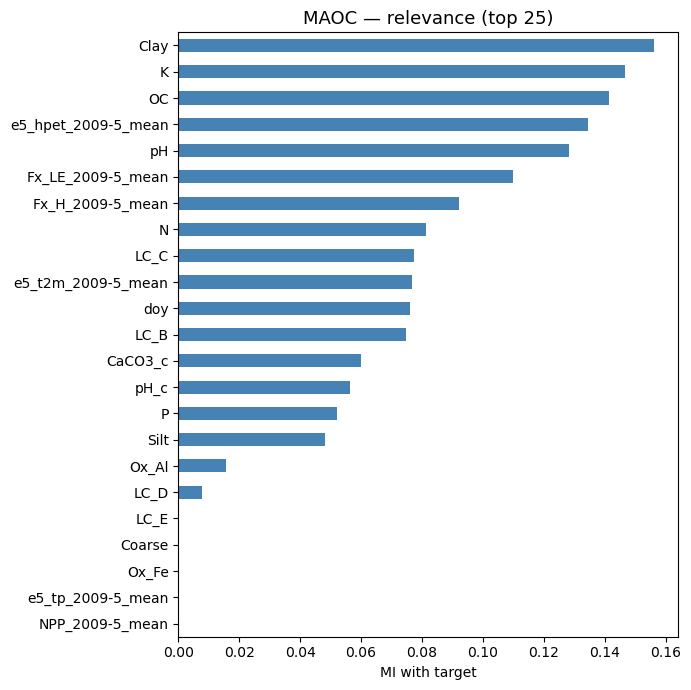

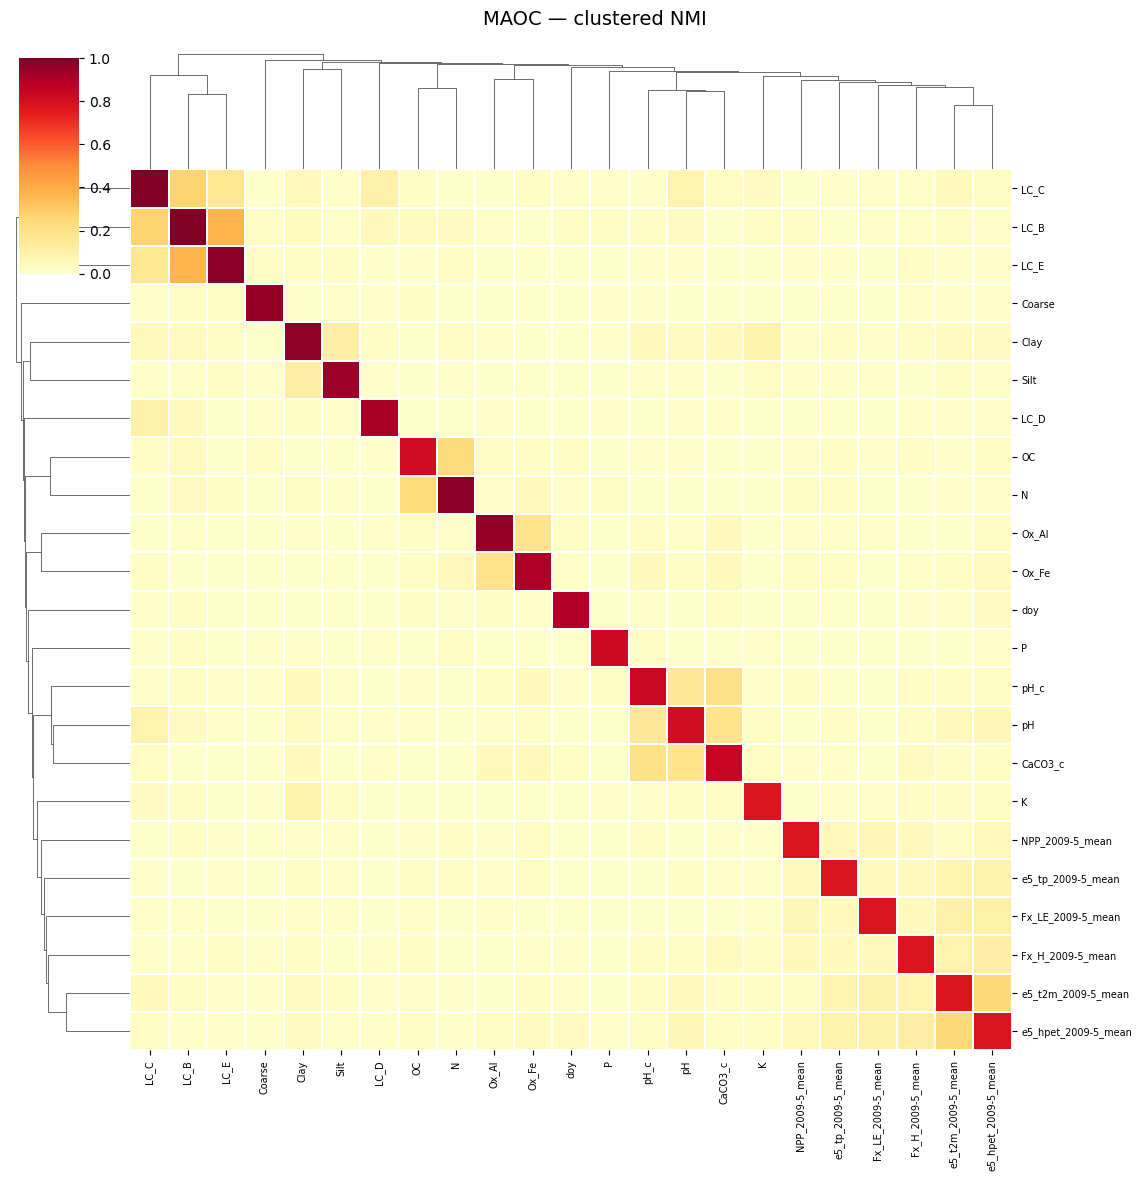


=== MAOC: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
2,LC_B,LC_E,0.366,0.0748,0.0000
0,LC_B,LC_C,0.269,0.0748,0.0773
209,e5_t2m_2009-5_mean,e5_hpet_2009-5_mean,0.249,0.0768,0.1346
243,OC,N,0.235,0.1413,0.0814
174,pH_c,CaCO3_c,0.195,0.0563,0.0599
186,pH,CaCO3_c,0.183,0.1283,0.0599
133,Ox_Al,Ox_Fe,0.181,0.0157,0.0000
23,LC_C,LC_E,0.167,0.0773,0.0000
162,pH_c,pH,0.150,0.0563,0.1283
190,Fx_H_2009-5_mean,e5_hpet_2009-5_mean,0.121,0.0921,0.1346


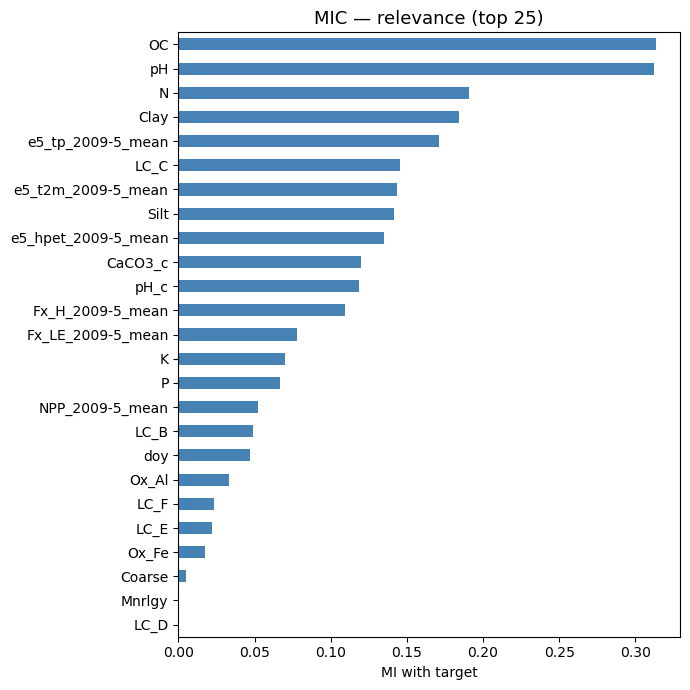

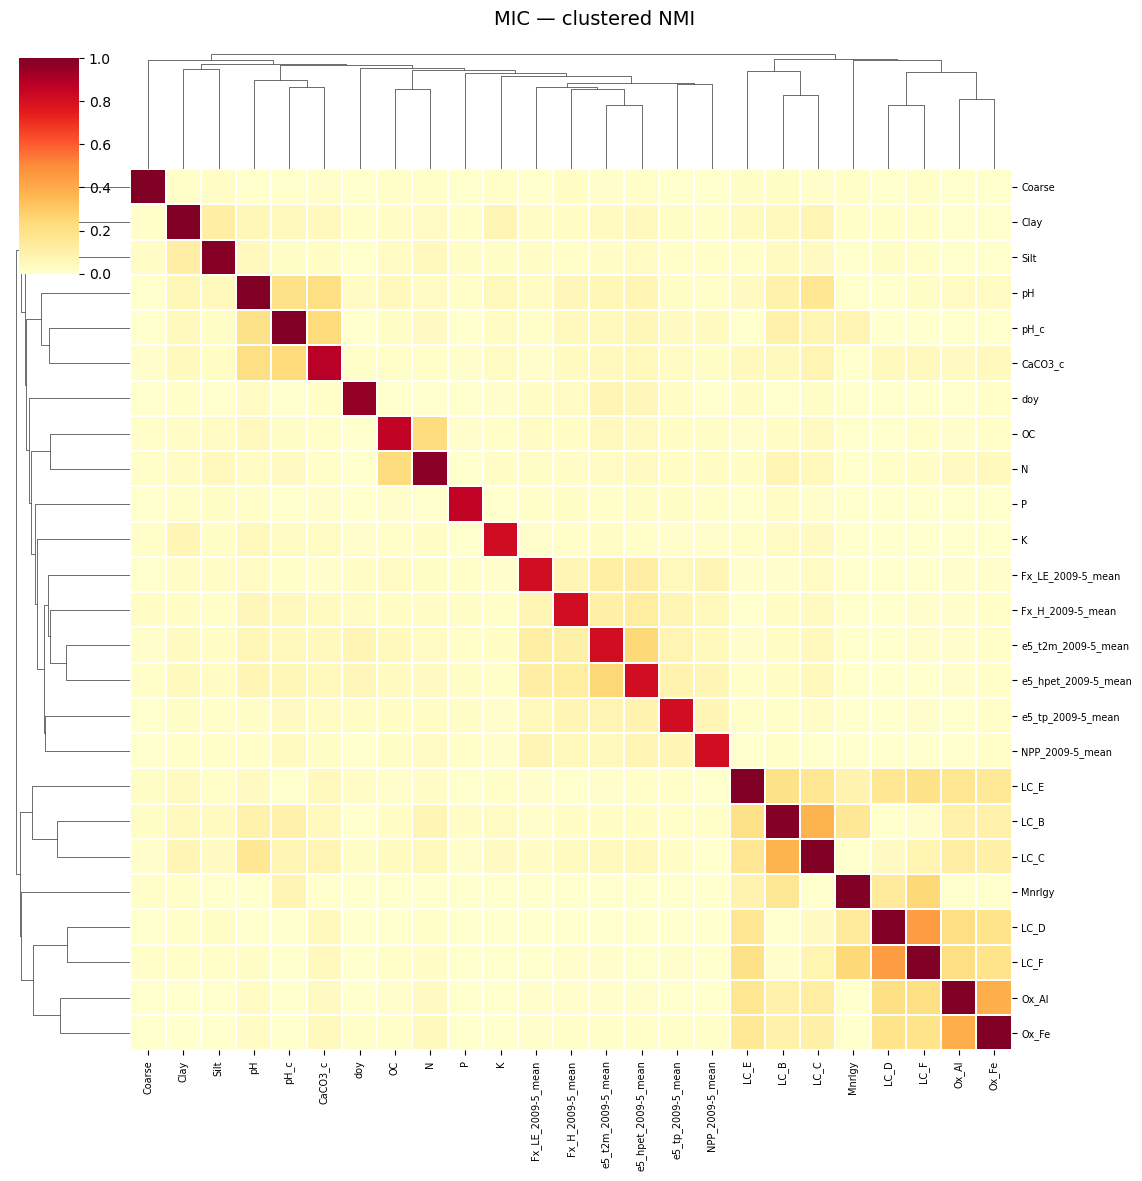


=== MIC: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
48,LC_D,LC_F,0.452,0.0000,0.0237
180,Ox_Al,Ox_Fe,0.390,0.0331,0.0174
0,LC_B,LC_C,0.369,0.0489,0.1453
256,e5_t2m_2009-5_mean,e5_hpet_2009-5_mean,0.249,0.1438,0.1350
93,LC_F,Mnrlgy,0.249,0.0237,0.0000
221,pH_c,CaCO3_c,0.237,0.1188,0.1199
290,OC,N,0.225,0.3136,0.1911
94,LC_F,Ox_Al,0.210,0.0237,0.0331
233,pH,CaCO3_c,0.209,0.3120,0.1199
53,LC_D,Ox_Al,0.208,0.0000,0.0331


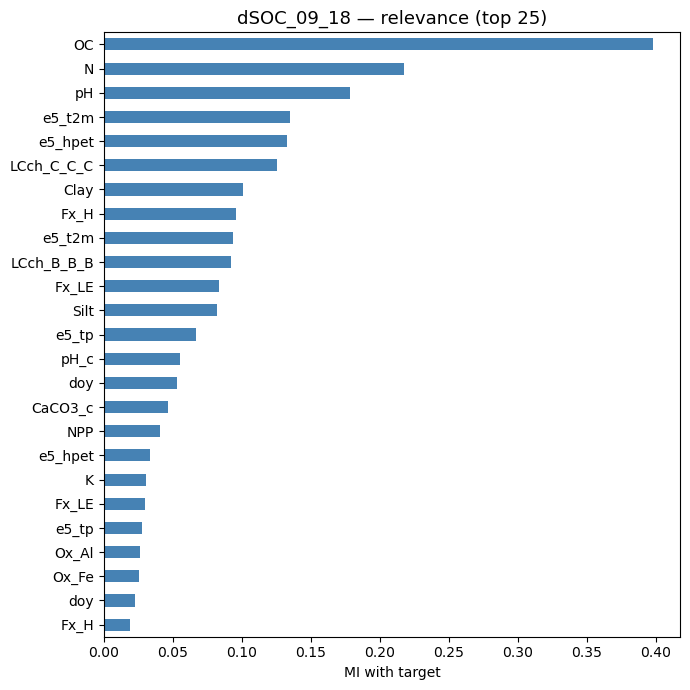

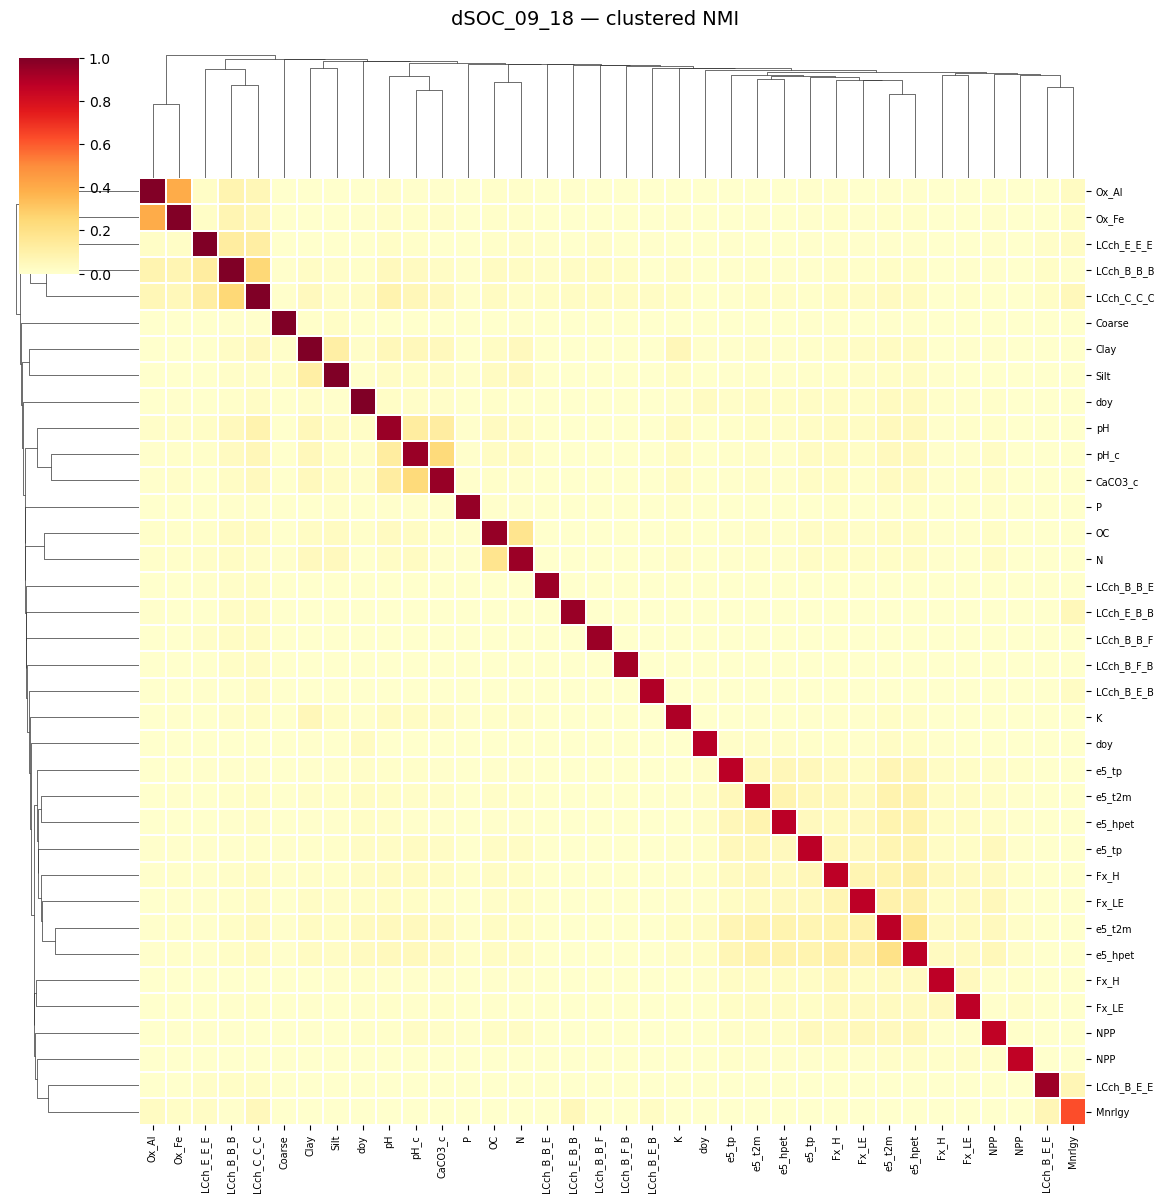


=== dSOC_09_18: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
377,Ox_Al,Ox_Fe,0.398,0.0264,0.0256
5,LCch_B_B_B,LCch_C_C_C,0.248,0.0920,0.1255
439,pH_c,CaCO3_c,0.238,0.0553,0.0466
565,e5_t2m,e5_hpet,0.198,0.1348,0.1324
620,OC,N,0.178,0.3975,0.2176
420,pH_c,pH,0.128,0.0553,0.1781
7,LCch_B_B_B,LCch_E_E_E,0.126,0.0920,0.0169
458,pH,CaCO3_c,0.124,0.1781,0.0466
196,LCch_C_C_C,LCch_E_E_E,0.119,0.1255,0.0169
279,Clay,Silt,0.112,0.1011,0.0816


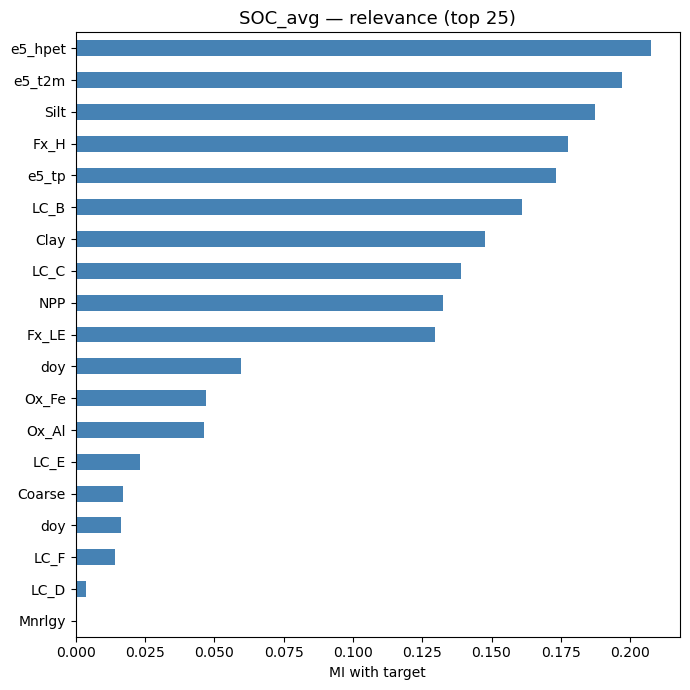

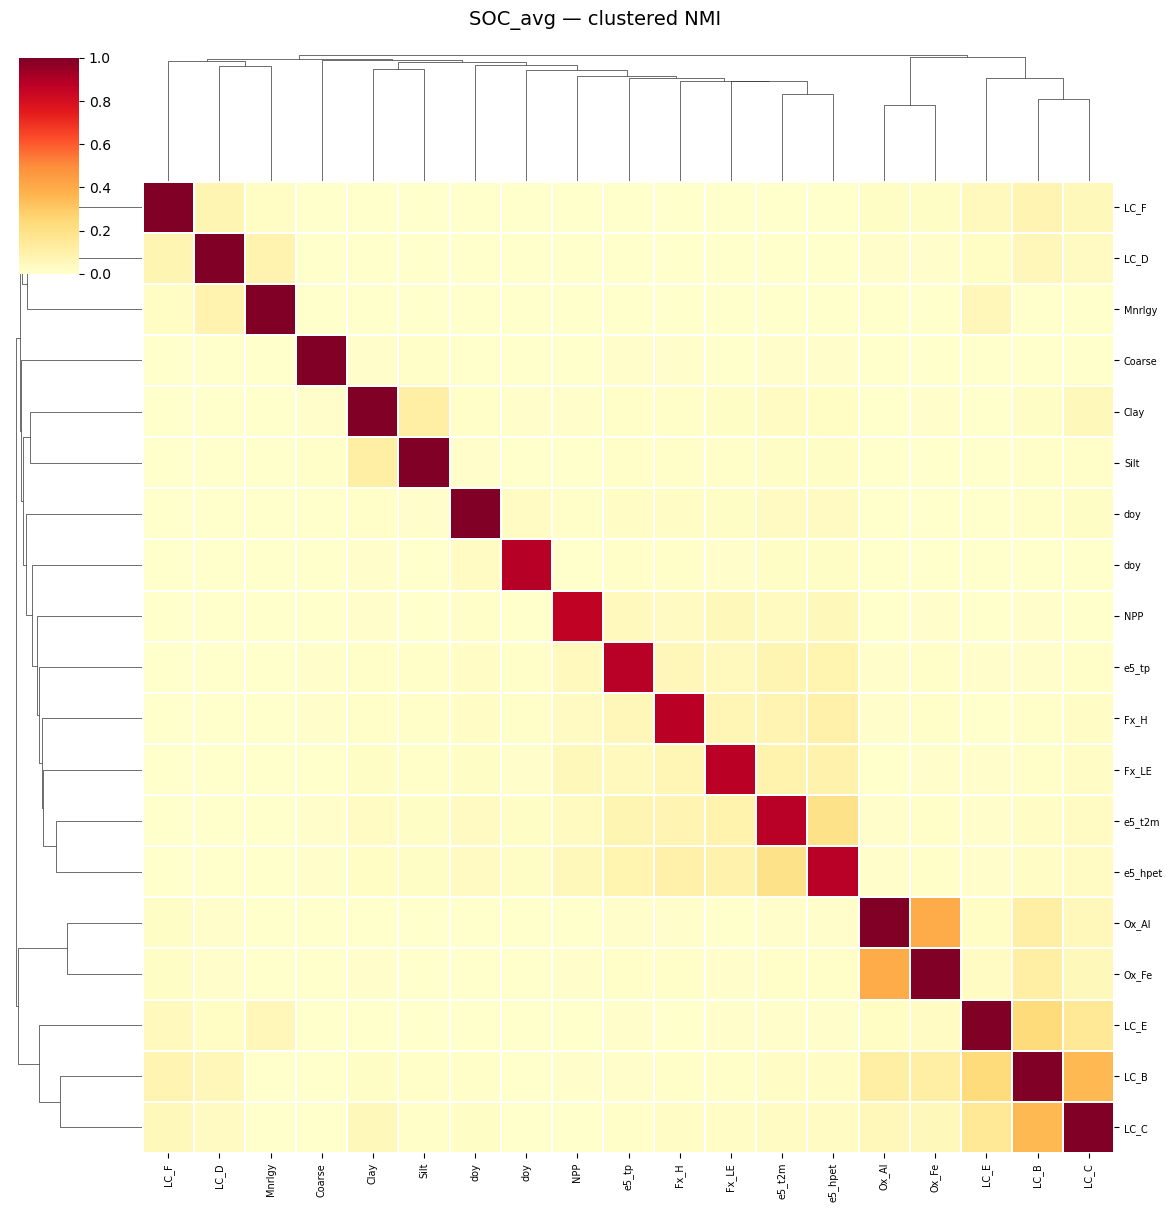


=== SOC_avg: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
126,Ox_Al,Ox_Fe,0.399,0.0462,0.0470
0,LC_B,LC_C,0.355,0.1609,0.1389
2,LC_B,LC_E,0.232,0.1609,0.0232
157,e5_t2m,e5_hpet,0.193,0.1969,0.2076
19,LC_C,LC_E,0.154,0.1389,0.0232
8,LC_B,Ox_Al,0.116,0.1609,0.0462
9,LC_B,Ox_Fe,0.113,0.1609,0.0470
80,Clay,Silt,0.111,0.1476,0.1875
146,Fx_H,e5_hpet,0.100,0.1775,0.2076
152,Fx_LE,e5_hpet,0.093,0.1295,0.2076


In [1]:
%matplotlib inline
# loop over targets
from config import TARGET_CONFIG
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import pickle
import pandas as pd
with open("1_preprocessed_intermediate.pkl", "rb") as f:
    df = pickle.load(f)


def nmi_pair(x, y, random_state=42):
  x = np.asarray(x).ravel()
  y = np.asarray(y).ravel()
  mi = mutual_info_regression(x.reshape(-1, 1), y, random_state=random_state)[0]
  def entropy(v):
      v = np.asarray(v).ravel()
      _, counts = np.unique(v, return_counts=True)
      p = counts / counts.sum()
      return -(p * np.log(p + 1e-12)).sum()
  hx, hy = entropy(x), entropy(y)
  if hx + hy == 0:
      return 0.0
  return float(np.clip(2 * mi / (hx + hy), 0, 1))

nmi_results = {}
for target in TARGET_CONFIG:
    # get potential predictors
    y = df[TARGET_CONFIG[target]['target_name']]
    y_log = np.log1p(df[TARGET_CONFIG[target]['target_name']])
    categoricals = pd.get_dummies(df[TARGET_CONFIG[target]['categoricals']], drop_first=False)
    continuous = df[TARGET_CONFIG[target]['predictors']]
    continuous_log = np.log1p(df[TARGET_CONFIG[target]['log_predictors']])
    X = pd.concat([categoricals, continuous, continuous_log], axis=1)
    # separate train and test
    train_mask = df['split'] != 'test'
    nan_mask = df[TARGET_CONFIG[target]['target_name']].notna()
    y, y_log, X = y[train_mask & nan_mask], y_log[train_mask & nan_mask], X[train_mask & nan_mask]
    X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns, index=X.index)
    X = X[X.columns[X.nunique() > 1]] # remove where no info
    X = X[[c for c in X.columns if not (X[c].nunique() == 2 and X[c].mean() < 0.01)]] # remove where no info
    relevance = pd.Series(mutual_info_regression(X, y, random_state=42), index=X.columns).sort_values(ascending=False)
    n = X.shape[1]
    nmi_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            nmi_ij = nmi_pair(X.iloc[:, i].values, X.iloc[:, j].values)
            nmi_matrix[i, j] = nmi_matrix[j, i] = nmi_ij

    nmi_df = pd.DataFrame(nmi_matrix, index=X.columns, columns=X.columns)
    nmi_results[target] = {'relevance': relevance, 'nmi_df': nmi_df, 'n_features': len(X.columns)}



def short_label(name, max_len=20):
    """Clay_2009 -> Clay; lc1_2_2009_F -> LC_F; LC_change_... -> LCch_..."""
    s = name
    s = re.sub(r'_2009$|_2015$|_2018$|_avg_09_15_18$|_linreg_slope$', '', s)
    s = re.sub(r'^lc1_2_\d+_', 'LC_', s)
    s = re.sub(r'^LC_change_09_15_18_', 'LCch_', s)
    s = re.sub(r'Fluxcom_', 'Fx_', s)
    s = re.sub(r'era5_land_', 'e5_', s)
    s = re.sub(r'MODIS_NPP', 'NPP', s)
    s = re.sub(r'HALA_\d+gps_topsoil', 'Mnrlgy', s)
    return s[:max_len]

def plot_relevance_bar(target, relevance, save=True):
    rel = relevance.copy()
    rel.index = [short_label(c) for c in rel.index]
    ax = rel.head(25).iloc[::-1].plot.barh(color='steelblue', figsize=(7, 7))
    ax.set_xlabel('MI with target')
    ax.set_title(f'{target} — relevance (top 25)', fontsize=13)
    plt.tight_layout()
    if save:
        plt.savefig(f'figures/relevance_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
def plot_nmi_clustermap(target, nmi_df, save=True):
    labels = [short_label(c) for c in nmi_df.columns]
    mat = nmi_df.copy()
    mat.index = labels
    mat.columns = labels

    g = sns.clustermap(
        mat, cmap='YlOrRd', vmin=0,
        figsize=(12, 12), linewidths=0.2,
        xticklabels=True, yticklabels=True,
        dendrogram_ratio=0.12,
    )
    g.ax_heatmap.tick_params(axis='x', labelsize=7, rotation=90)
    g.ax_heatmap.tick_params(axis='y', labelsize=7)
    g.fig.suptitle(f'{target} — clustered NMI', y=1.02, fontsize=14)

    if save:
        g.savefig(f'figures/nmi_cluster_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
def top_redundant_pairs(target, relevance, nmi_df, nmi_threshold=0.3, top_k=20):
    rows = []
    cols = nmi_df.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = nmi_df.iloc[i, j]
            if v >= nmi_threshold:
                rows.append({
                    'feature_a': short_label(cols[i]),
                    'feature_b': short_label(cols[j]),
                    'NMI': round(v, 3),
                    'MI_a': round(relevance[cols[i]], 4),
                    'MI_b': round(relevance[cols[j]], 4),
                })
    out = pd.DataFrame(rows).sort_values('NMI', ascending=False).head(top_k)
    print(f'\n=== {target}: top redundant pairs (NMI >= {nmi_threshold}) ===')
    display(out)
    return out
for target, res in nmi_results.items():
    plot_relevance_bar(target, res['relevance'])
    plot_nmi_clustermap(target, res['nmi_df'])
    top_redundant_pairs(target, res['relevance'], res['nmi_df'], nmi_threshold=0.0)

In [2]:
# manually remove predictors

Machine Learning

Total time: 9.14 min
new: pred_MAOC_median_XGB-1_inf_MAOC_index_2015
new: pred_MAOC_median_XGB-1_inf_MAOC_index_2018
new: pred_MAOC_median_XGB-1_inf_MAOC_index_2009
new: pred_MIC_median_XGB-1_inf_Cmic_index_2015
new: pred_MIC_median_XGB-1_inf_Cmic_index_2018
new: pred_MIC_median_XGB-1_inf_Cmic_index_2009
new: pred_dSOC_09_18_median_XGB-n_inf_SOC_linreg_slope
new: pred_SOC_avg_median_XGB-n_inf_SOC_linreg_slope


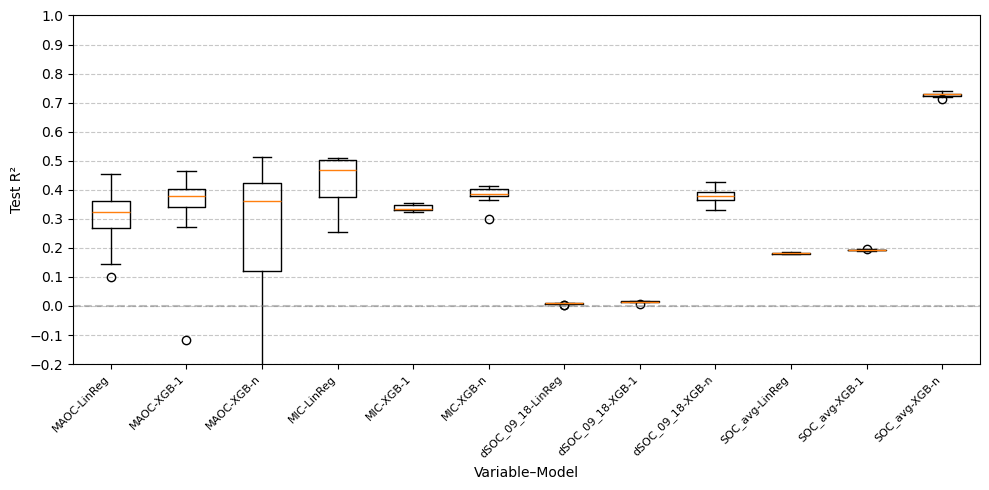

In [1]:
import time
t0 = time.perf_counter()
import numpy as np
import pickle
import pandas as pd
from joblib import Parallel, delayed
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

######################################## load ########################################
from config import TARGET_CONFIG, TRAIN_DEFAULTS
from models import get_models
models = get_models()

# Load the saved preprocessed dataframe from pickle, and save to a "wide" CSV for easy summary/stats.
import pickle
with open("1_preprocessed_intermediate.pkl", "rb") as f:
    df = pickle.load(f)

######################################## define ########################################
def process_one_fold(var, fold, df, TARGET_CONFIG):
    ### load info
    config = TARGET_CONFIG[var] # info (targets, predictors, inference, log...)
    target_name = config["target_name"] # target name
    ### prepare data
    onehot_cols, _ = get_onehot_cols_for_config(df, config) # get data of 1-hot variables
    pred_cols = list(config['predictors']) + list(config['log_predictors']) + onehot_cols # all potential predictors together (1-hot might get selected individually)
    n_normal = len(config['predictors']) # number of normal distributed predictors
    n_log = len(config['log_predictors']) # numer of log normal distributed predictors
    test_data = df[(df['split'] == 'test') & (df[target_name].notna())] # valid test rows
    X_test, y_test  = test_data[pred_cols].to_numpy(dtype=float), test_data[target_name].to_numpy(dtype=float) # get test X and y as array
    X_test[:, n_normal:n_normal + n_log] = np.log1p(X_test[:, n_normal:n_normal + n_log]) # log respective predictors (looks correct) 
    train_fit = df[(df['split'] != 'test') & (df['split'] != fold) & (df[target_name].notna())] # valid train samples       (not in test of validation)
    val_fit = df[(df['split'] != 'test') & (df['split'] == fold) & (df[target_name].notna())]   # valid validation samples  (not in test but in validation)
    train_all = df[(df['split'] != 'test') & (df['split'] != fold)]
    val_all = df[(df['split'] != 'test') & (df['split'] == fold)]
    test_all = df[(df['split'] == 'test')]
    train_idx = train_all.index.to_numpy()
    val_idx = val_all.index.to_numpy()
    test_idx = test_all.index.to_numpy()
    X_train = train_fit[pred_cols].to_numpy(dtype=float)
    y_train = train_fit[target_name].to_numpy(dtype=float)
    X_val = val_fit[pred_cols].to_numpy(dtype=float)
    y_val = val_fit[target_name].to_numpy(dtype=float)
    X_train_all = train_all[pred_cols].to_numpy(dtype=float)
    X_val_all = val_all[pred_cols].to_numpy(dtype=float)
    X_test_all = test_all[pred_cols].to_numpy(dtype=float)
    y_train_all = train_all[target_name].to_numpy(dtype=float)
    X_train = np.asarray(X_train, dtype=float, order='C').copy() # order='C' -> row major
    X_val = np.asarray(X_val, dtype=float, order='C').copy() # rearrange array
    X_train[:, n_normal:n_normal + n_log] = np.log1p(X_train[:, n_normal:n_normal + n_log]) # log respective predictors
    X_val[:, n_normal:n_normal + n_log] = np.log1p(X_val[:, n_normal:n_normal + n_log]) # log respective predictors
    preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]) # implace empty predictors with median & z-score
    X_train_p = preprocessor.fit_transform(X_train) # get median (for imputation), mean and var (for z-score) on train
    X_val_p = preprocessor.transform(X_val) # apply with train stats on val predictors
    X_test_p = preprocessor.transform(X_test) # apply with train stats on test predictors
    def to_signed_log(y): # log the abs value and give it sign: log of negative (changes) makes problems otherwise
        return np.sign(y) * np.log1p(np.abs(y))
    def from_signed_log(y_log): # function to revert (when prediction)
        y_log = np.clip(y_log, -np.log(np.finfo(np.float64).max), np.log(np.finfo(np.float64).max))
        return np.sign(y_log) * np.expm1(np.abs(y_log))
    y_train_log = to_signed_log(y_train) # log train target (if negative special: vide function)
    y_val_log = to_signed_log(y_val) # log val target (if negative special: vide function)
    ### prepare predictions
    inference_bundles = []
    for raw_inf in config.get('inference') or []:
        inf = { "target_name": raw_inf["target_name"], "predictors": tuple(raw_inf.get("predictors", config["predictors"])), "log_predictors": tuple(raw_inf.get("log_predictors", config["log_predictors"])), "categoricals": list(raw_inf.get("categoricals", config.get("categoricals", []))) }
        oh_i, _ = get_onehot_cols_for_config(df, inf)
        pc_i = list(inf['predictors']) + list(inf['log_predictors']) + oh_i
        nn_i = len(inf['predictors'])
        nl_i = len(inf['log_predictors'])
        tn_i = inf['target_name']
        inference_bundles.append({'target_name': tn_i, 'X_train': train_all[pc_i].to_numpy(dtype=float), 'X_val': val_all[pc_i].to_numpy(dtype=float), 'X_test': test_all[pc_i].to_numpy(dtype=float), 'y_train': _y_column_if_present(train_all, tn_i), 'y_val': _y_column_if_present(val_all, tn_i), 'y_test': _y_column_if_present(test_all, tn_i), 'n_normal': nn_i, 'n_log': nl_i})
    ### train
    fold_results = []
    for model_name in TRAIN_DEFAULTS['models']: # loop over methods (LR, PLR, XGB...)
        model_config = models[model_name] # get info on model
        param_grid = model_config.get('params', {}) or {} # create latin hypercube of hyperparameter combinations (if HP opt...)
        best_val_r2 = -np.inf # init best metric (worst R2 in -inf)
        best_result = None
        for params_combo in ParameterGrid(param_grid) if param_grid else [{}]: # loop over hyperparameter combos
            ### select features and predict (original and log-transformed target)
            train_r2_raw, val_r2_raw, test_r2_raw, selected_raw = select_features_and_predict(X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, y_train, y_val, model_config, params_combo, TRAIN_DEFAULTS['max_features'])
            train_r2_log, val_r2_log, test_r2_log, selected_log = select_features_and_predict(X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, y_train_log, y_val_log, model_config, params_combo, TRAIN_DEFAULTS['max_features'], inverse_pred=from_signed_log)
            ### pick if best combo
            if val_r2_log > best_val_r2:
                best_val_r2 = val_r2_log
                best_result = {'train r2': train_r2_log, 'val r2': val_r2_log, 'test r2': test_r2_log, 'params': params_combo, 'selected': selected_log, 'target_logged': True}
            elif val_r2_raw > best_val_r2:
                best_val_r2 = val_r2_raw
                best_result = {'train r2': train_r2_raw, 'val r2': val_r2_raw, 'test r2': test_r2_raw, 'params': params_combo, 'selected': selected_raw, 'target_logged': False}
        ### retrain best model
        if best_result is not None: # if any haperparameter combo worked:
            sel = best_result['selected'] # selected features
            m_final = _make_model(model_config, best_result['params'], n_features=len(sel)) # initialize model
            yt = to_signed_log(y_train) if best_result['target_logged'] else y_train # target log-transformed?          
            m_final.fit(X_train_p[:, sel], yt) # retrain
            ### predict
            def _predict_from_Xp(Xp):
                raw = m_final.predict(Xp[:, sel])
                return from_signed_log(raw) if best_result['target_logged'] else raw
            inference_metrics = []
            inference_preds = []
            for ib in inference_bundles:
                rec = dict(inference_target=ib['target_name'], train_r2=np.nan, val_r2=np.nan, test_r2=np.nan, frozen_main_model=False)
                pred_pack = dict(inference_target=ib['target_name'], pred_train=None, pred_val=None, pred_test=None)
                try:
                    Xtr = np.asarray(ib['X_train'], dtype=float, order='C').copy()
                    Xva = np.asarray(ib['X_val'], dtype=float, order='C').copy()
                    Xte = np.asarray(ib['X_test'], dtype=float, order='C').copy()
                    nn, nl = ib['n_normal'], ib['n_log']
                    Xtr[:, nn:nn + nl] = np.log1p(Xtr[:, nn:nn + nl])
                    Xva[:, nn:nn + nl] = np.log1p(Xva[:, nn:nn + nl])
                    Xte[:, nn:nn + nl] = np.log1p(Xte[:, nn:nn + nl])
                    ytr_i, yva_i, yte_i = ib['y_train'], ib['y_val'], ib['y_test']
                    if Xtr.shape[1] == X_train.shape[1]:
                        Xtr_p = preprocessor.transform(Xtr)
                        Xva_p = preprocessor.transform(Xva)
                        Xte_p = preprocessor.transform(Xte)
                        rec['frozen_main_model'] = True
                        ptr = _predict_from_Xp(Xtr_p)
                        pva = _predict_from_Xp(Xva_p)
                        pte = _predict_from_Xp(Xte_p)
                    else:
                        prep_i = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
                        Xtr_p = prep_i.fit_transform(Xtr)
                        Xva_p = prep_i.transform(Xva)
                        Xte_p = prep_i.transform(Xte)
                        m_i = _make_model(model_config, best_result['params'], n_features=len(sel))
                        # Refit on inference-year X; use inference y only if present (≥2 finite), else main y_train
                        use_inf_y = ytr_i is not None and np.isfinite(ytr_i).sum() >= 2
                        y_fit_source = ytr_i if use_inf_y else y_train_all
                        y_fit = to_signed_log(y_fit_source) if tl else y_fit_source
                        fit_m = np.isfinite(y_fit) & np.all(np.isfinite(Xtr_p[:, sel]), axis=1)
                        if fit_m.sum() < 2:
                            inference_metrics.append(rec)
                            inference_preds.append(pred_pack)
                            continue
                        m_i.fit(Xtr_p[fit_m][:, sel], y_fit[fit_m])
                        def _pred_i(Xp):
                            r = m_i.predict(Xp[:, sel])
                            return from_signed_log(r) if tl else r
                        ptr, pva, pte = _pred_i(Xtr_p), _pred_i(Xva_p), _pred_i(Xte_p)
                    rec['train r2'] = _r2_masked(ytr_i, ptr)
                    rec['val r2'] = _r2_masked(yva_i, pva)
                    rec['test r2'] = _r2_masked(yte_i, pte)
                    pred_pack['pred_train'] = ptr
                    pred_pack['pred_val'] = pva
                    pred_pack['pred_test'] = pte
                except (ValueError, np.linalg.LinAlgError, RuntimeError):
                    pass
                inference_metrics.append(rec)
                inference_preds.append(pred_pack)
            def _prep_full_X(X_raw):
                X = np.asarray(X_raw, dtype=float, order='C').copy()
                X[:, n_normal:n_normal + n_log] = np.log1p(X[:, n_normal:n_normal + n_log])
                return preprocessor.transform(X)
            pred_train = _predict_from_Xp(_prep_full_X(X_train_all))
            pred_val = _predict_from_Xp(_prep_full_X(X_val_all))
            pred_test = _predict_from_Xp(_prep_full_X(X_test_all))
            ### output
            fold_results.append({'var': var, 'fold': fold, 'model': model_name, 
                        'train r2': best_result['train r2'], 'val r2': best_result['val r2'], 'test r2': best_result['test r2'], 
                        'params': best_result['params'], 'target_logged': best_result['target_logged'], 'selected_predictors': [pred_cols[i] for i in sel], 
                        'pred_train': pred_train, 'pred_val': pred_val, 'pred_test': pred_test, 
                        'train_idx': train_idx, 'val_idx': val_idx, 'test_idx': test_idx, 
                        'selected': sel, 'inference_metrics': inference_metrics, 'inference_preds': inference_preds})
    return fold_results

def select_features_and_predict(X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, y_train_fit, y_val_fit, model_config, params_combo, max_features, inverse_pred=None):
    ### select features 
    selected = forward_select(X_train_p, X_val_p, y_train_fit, y_val_fit, model_config, params_combo, max_features)
    ### retrain with optimal n_features
    m = _make_model(model_config, params_combo, n_features=len(selected))
    m.fit(X_train_p[:, selected], y_train_fit)
    ### predict
    def _predict(Xp):
        pred = m.predict(Xp[:, selected])
        return inverse_pred(pred) if inverse_pred else pred
    pred_train = _predict(X_train_p)
    pred_val = _predict(X_val_p)
    pred_test = _predict(X_test_p)
    return r2_score(y_train, pred_train), r2_score(y_val, pred_val), r2_score(y_test, pred_test), selected

def get_onehot_cols_for_config(df, config):
    """Resolve categorical columns from df. config uses 'categoricals' or 'onehot_prefixes'."""
    prefixes = config.get('categoricals', config.get('onehot_prefixes', [])) # list with prefixes of all desired 1-hot columns
    cols = []
    specs = {}
    for p in prefixes: # loop over prefixes/categoricals
        group_cols = [c for c in df.columns if c.startswith(f'{p}_')] # get the columns which have respective prefix
        if group_cols: # if any found
            cols.extend(group_cols) # add columns (data)
            specs[p] = group_cols # add column names
    return cols, specs # return data and column names

def _make_model(model_config, params_combo, n_features=None):
    """Create model with params. If n_features given, cap n_components for PLSR/PCA-like estimators."""
    m = clone(model_config['model']) # clone the model with hyperparameters, so standard remains untouched (not fitted to anything)
    params = dict(params_combo) if params_combo else {} # use hyperparameter combination if given... else use standard hyperparameters
    if n_features is not None and 'n_components' in params: # if n_components is a hyperparameter -> only relevant for PLSR
        params['n_components'] = min(params['n_components'], n_features) # use the ones specified, or if less predictors then n of predictors
    if params: # if hyperparameters to specify 
        m.set_params(**params) # specify
    return m # return model

def forward_select(X_train_p, X_val_p, y_train, y_val, model_config, params_combo, max_features):
    """Additive forward feature selection: iteratively add feature that improves val R² most."""
    n_features = X_train_p.shape[1] # number of possible features
    selected_idx = [] # to store the indices of selected predictors
    remaining = list(range(n_features)) # indices of remaining predictors which could later be selected
    best_val_r2 = -np.inf # start at worst possible R2
    for _ in range(min(max_features, n_features)): # loop over max features (except there are less than defined max)
        best_c, best_score = None, -np.inf # initialize best predictor and corresponding R2
        for c in remaining: # loop over (remaining) possible predictors
            idxs = selected_idx + [c] # formerly selected + possible new predictor
            n_cols = len(idxs) # number of predictors
            try:
                m = _make_model(model_config, params_combo, n_features=n_cols) # create model with respective hyperparameters
                m.fit(X_train_p[:, idxs], y_train) # fit model on train of the predictors (formerly selected + possible new predictor)
                pred = m.predict(X_val_p[:, idxs]) # predict for val
                if not np.all(np.isfinite(pred)): # if any predicted value is corrupt 
                    score = -np.inf # -> worst
                else: # if val prediction worked
                    score = r2_score(y_val, pred) # calculate r2 (with sk_learn)
            except (ValueError, np.linalg.LinAlgError, RuntimeError): # if even fitting didn't work
                score = -np.inf # -> worst
            if score > best_score: # if val R2 better than any before
                best_score, best_c = score, c # select/overwrite
        if best_c is None or best_score <= best_val_r2: # if no possible additional predictor makes predictions better:
            break # don't select further predictor: less predictors than max
        best_val_r2 = best_score # but if additional predictor helped: new best score
        selected_idx.append(best_c) # but if additional predictor helped: add best new predictor to selection
        remaining.remove(best_c) # remove the selected from the ones to test in next round
    return selected_idx # return indices of selected predictors

def _r2_masked(y, pred):
    if y is None:
        return np.nan
    m = np.isfinite(np.asarray(y)) & np.isfinite(np.asarray(pred))
    if m.sum() < 2:
        return np.nan
    return r2_score(np.asarray(y)[m], np.asarray(pred)[m])

def _y_column_if_present(frame, col_name):
    """Return float numpy y for rows in frame, or None if column missing (no ground truth for that target)."""
    if col_name not in frame.columns:
        return None
    return frame[col_name].to_numpy(dtype=float)

######################################## compute ########################################
# define individual tasks to parallelize
tasks = []
for var in TARGET_CONFIG.keys():
    for fold in range(10):
        tasks.append((var, fold, df, TARGET_CONFIG))
# Parallel:    runs individual processes (own memory) not threads (shared memory) -> one per target and fold
# delayed:      creates argument combos for the function which is processed per task: process_one_fold
results = Parallel(n_jobs=TRAIN_DEFAULTS['N_JOBS'], backend='loky')(delayed(process_one_fold)(*task) for task in tasks)

######################################## post processing ########################################
# Each fold returns a list of dicts (one per model); flatten
results_flat = [row for fold_results in results for row in fold_results]

# One row per (var, fold, model): hyperparameters dict, log-target flag, ordered selected predictor names
selection_meta_df = pd.DataFrame([
    {
        'var': r['var'],
        'fold': r['fold'],
        'model': r['model'],
        'params': r['params'],
        'target_logged': r['target_logged'],
        'selected_predictors': r['selected_predictors'],
        'inference_metrics': r.get('inference_metrics', []),
        'train r2': r['train r2'], 
        'val r2': r['val r2'],
        'test r2': r['test r2']
    }
    for r in results_flat])

_results_exclude = ('pred_train', 'pred_val', 'pred_test', 'train_idx', 'val_idx', 'test_idx', 'inference_preds',)
results_df = pd.DataFrame([
    {**{k: v for k, v in r.items() if k not in _results_exclude},
     'params': str(r['params'])}
    for r in results_flat])
# Long-form inference rows (one row per var/fold/model/inference_target) for filtering and tables
inf_rows = []
for r in results_flat:
    for im in r.get('inference_metrics') or []:
        inf_rows.append({
            'var': r['var'],
            'fold': r['fold'],
            'model': r['model'],
            'inference_target': im['inference_target'],
            'inference_train_r2': im['train r2'],
            'inference_val_r2': im['val r2'],
            'inference_test_r2': im['test r2'],
            'inference_frozen_main_model': im.get('frozen_main_model', False),
        })
inference_results_df = pd.DataFrame(inf_rows)

# Build output df: original df + one column per (var, fold, model) with train/val/test predictions
# on every row in each split (not only rows with observed target). Inference preds use the same splits.
out_df = df.copy()
pred_cols = []
for r in results_flat:
    pred_cols.append(f"pred_{r['var']}_fold{r['fold']}_{r['model']}")
    pred_cols.extend(
        f"pred_{r['var']}_fold{r['fold']}_{r['model']}_inf_{str(ip['inference_target']).replace(' ', '_').replace('/', '_')}"
        for ip in (r.get('inference_preds') or [])
        if ip.get('pred_train') is not None
    )
out_df = pd.concat([out_df, pd.DataFrame(np.nan, index=out_df.index, columns=pred_cols)], axis=1)
for r in results_flat:
    col = f"pred_{r['var']}_fold{r['fold']}_{r['model']}"
    out_df.loc[r['train_idx'], col] = r['pred_train']
    out_df.loc[r['val_idx'], col] = r['pred_val']
    out_df.loc[r['test_idx'], col] = r['pred_test']
    for ip in r.get('inference_preds') or []:
        if ip.get('pred_train') is None:
            continue
        suf = str(ip['inference_target']).replace(' ', '_').replace('/', '_')
        icol = f"pred_{r['var']}_fold{r['fold']}_{r['model']}_inf_{suf}"
        out_df.loc[r['train_idx'], icol] = ip['pred_train']
        out_df.loc[r['val_idx'], icol] = ip['pred_val']
        out_df.loc[r['test_idx'], icol] = ip['pred_test']
_pred_cols = [c for c in out_df.columns if c.startswith('pred_')]
_n_inf = sum(1 for c in _pred_cols if '_inf_' in c)

import matplotlib.pyplot as plt
model_order = [m for m in TRAIN_DEFAULTS['models'] if m in results_df['model'].values]
combo_order = [f"{v}-{m}" for v in TARGET_CONFIG.keys() for m in model_order]
data = [results_df[(results_df['var'] == v) & (results_df['model'] == m)]['test r2'].values
    for v in TARGET_CONFIG.keys() for m in model_order]
plt.figure(figsize=(max(10, len(combo_order) * 0.5), 5))
plt.boxplot(data, tick_labels=combo_order)
plt.ylabel('Test R²')
plt.xlabel('Variable–Model')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylim(-0.2, 1.0)
plt.yticks(np.arange(-0.2, 1.05, 0.1))
plt.grid(axis='y', which='both', linestyle='--', alpha=0.7)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figures/predict.png', dpi=150, bbox_inches='tight')
print(f"Total time: {(time.perf_counter() - t0) / 60:.2f} min")

from config import TARGET_CONFIG, use_model
df = out_df
for var in use_model:
    for inference in TARGET_CONFIG[var]["inference"]:
        columns = [f"pred_{var}_fold{f}_{use_model[var]}_inf_{inference['target_name'].replace(' ', '_')}" for f in range(10)]
        all_folds = df[columns]
        df[f"pred_{var}_median_{use_model[var]}_inf_{inference['target_name'].replace(' ', '_')}"] = all_folds.median(axis=1)
        print('new:', f"pred_{var}_median_{use_model[var]}_inf_{inference['target_name'].replace(' ', '_')}")

Save for use in hybrid modeling

In [2]:
with open("1_preprocessed.pkl", "wb") as f:
    pickle.dump(df, f)

Extract selected predictors

In [54]:
import pickle

with open("1_preprocessed.pkl", "rb") as f:
    df = pickle.load(f)


# Build a DataFrame of just rows where the `model` column matches the desired model for the corresponding variable (`var`)
plot_mask = []
for _, row in selection_meta_df.iterrows():
    var = row['var']
    model = row['model']
    # Only keep rows where the model matches the one used for this variable
    if var in use_model and use_model[var] == model:
        plot_mask.append(True)
    else:
        plot_mask.append(False)
plot_df = selection_meta_df.loc[plot_mask, ['var', 'model', 'fold', 'train r2', 'val r2', 'test r2', 'selected_predictors']]

# Compute sample counts for each split: train, val, test
def count_samples(row, split, fold):
    if split == 'test':
        mask = (
            (df['split'] == 'test') &
            (~df[TARGET_CONFIG[row['var']]['target_name']].isna())
        )
    elif split == 'val':
        mask = (
            (df['split'] == fold) &
            (~df[TARGET_CONFIG[row['var']]['target_name']].isna())
        )
    elif split == 'train':
        mask = (
            (df['split'] != row['fold']) &
            (df['split'] != 'test') &
            (~df[TARGET_CONFIG[row['var']]['target_name']].isna())
        )
    return df.loc[mask, :].shape[0]

plot_df['train_samples'] = [
    count_samples(row, 'train', row['fold'])
    for _, row in plot_df.iterrows()
]
plot_df['val_samples'] = [
    count_samples(row, 'val', row['fold'])
    for _, row in plot_df.iterrows()
]
plot_df['test_samples'] = [
    count_samples(row, 'test', row['fold'])
    for _, row in plot_df.iterrows()
]

# Create new columns 'Feature 1' ... up to max_features
max_features = TRAIN_DEFAULTS['max_features']
feature_cols = [f'Feat. {i+1}' for i in range(max_features)]
def unpack_predictors(row):
    preds = row['selected_predictors']
    # Fill up to max_features with '' if not enough predictors
    filled = list(preds) + [''] * (max_features - len(preds))
    return pd.Series(filled[:max_features], index=feature_cols)
plot_df[feature_cols] = plot_df.apply(unpack_predictors, axis=1)
plot_df = plot_df.drop(columns=['selected_predictors'])

# rename
def standardize_feature_names(df, feature_cols, name_map):
    new_df = df.copy()
    for col in feature_cols:
        new_df[col] = new_df[col].map(lambda v: name_map.get(v, v) if isinstance(v, str) else v)
    return new_df
feature_rename_map = {f'OC_{x}': 'OC' for x in [2009, 2015, 2018]}
feature_rename_map.update({f'N_{x}': 'N' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'K_{x}': 'K' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'P_{x}': 'P' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'doy_{x}': 'doy' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'pH_{x}': 'pH' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'Calc_{x}': 'Calc' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'HALA_{x}gps_topsoil': 'Mnrlgy' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'CaCO3_c_{x}': 'CaCO3' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'pH_c_{x}': 'pH' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'lc1_2_{x}_{s}': 'LC' for x in [2009, 2015, 2018] for s in ['C', 'D', 'B', 'E', 'F', 'H', 'A', 'G']})
feature_rename_map.update({f'era5_land_hpet_{x}-5_mean': 'PET' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'era5_land_tp_{x}-5_mean': 'TP' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'era5_land_t2m_{x}-5_mean': 'MAT' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'MODIS_NPP_{x}-5_mean': 'NPP' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'Fluxcom_LE_{x}-5_mean': 'LE' for x in [2009, 2015, 2018]})
feature_rename_map.update({f'Fluxcom_H_{x}-5_mean': 'H' for x in [2009, 2015, 2018]})
feature_rename_map['Fluxcom_H_avg_09_15_18'] = 'H'
feature_rename_map['Fluxcom_LE_avg_09_15_18'] = 'LE'
feature_rename_map['Fluxcom_LE_linreg_slope'] = 'dLE'
feature_rename_map['era5_land_t2m_avg_09_15_18'] = 'MAT'
feature_rename_map['era5_land_t2m_linreg_slope'] = 'dMAT'
feature_rename_map['era5_land_tp_avg_09_15_18'] = 'TP'
feature_rename_map['MODIS_NPP_avg_09_15_18'] = 'NPP'
feature_rename_map['era5_land_hpet_avg_09_15_18'] = 'PET'
feature_rename_map['era5_land_hpet_linreg_slope'] = 'dPET'
feature_rename_map['MODIS_NPP_linreg_slope'] = 'dNPP'
feature_rename_map['era5_land_tp_linreg_slope'] = 'dTP'
feature_rename_map['LC_change_09_15_18_C_C_C'] = 'Forest'
feature_rename_map['LC_change_09_15_18_D_D_D'] = 'Shrub'
feature_rename_map['LC_change_09_15_18_E_E_E'] = 'Grass'
feature_rename_map['LC_change_09_15_18_B_E_E'] = 'Crp_Grs'
feature_rename_map['LC_change_09_15_18_F_C_C'] = 'Br_Frst'
feature_rename_map['LC_change_09_15_18_C_C_F'] = 'Frst_Br'
feature_rename_map['N_avg_09_15_18'] = 'N'
feature_rename_map['K_avg_09_15_18'] = 'K'
feature_rename_map['pH_avg_09_15_18'] = 'pH'
feature_rename_map['pH_c_avg_09_15_18'] = 'pH'
feature_rename_map['doy_avg_09_15_18'] = 'doy'
feature_rename_map['doy_linreg_slope'] = 'ddoy'
feature_rename_map['OC_avg_09_15_18'] = 'OC'
feature_rename_map['Ox_Fe_2018'] = 'Fe'
feature_rename_map['Ox_Al_2018'] = 'Al'
plot_df = standardize_feature_names(plot_df, feature_cols, feature_rename_map)

# Save the current plot_df (before styling) for later use as df
plot_df_copy = plot_df.copy()

# color code
def string_colors(val):
    colors = {
        # Texture
        'Clay': 'background-color: #f5f5dc',  # Beige
        'Silt': 'background-color: #f5f5dc',  # Beige
        'Sand': 'background-color: #f5f5dc',  # Beige
        'Coarse': 'background-color: #f5f5dc',  # Beige
        # Land Cover
        'LC': 'background-color: #c6efce',  # Light green
        'Forest': 'background-color: #c6efce',  # Light green
        'Grass': 'background-color: #c6efce',  # Light green
        'Crp_Grs': 'background-color: #c6efce',  # Light green
        'Br_Frst': 'background-color: #c6efce',  # Light green
        'Frst_Br': 'background-color: #c6efce',  # Light green
        'Shrub': 'background-color: #c6efce',  # Light green
        # Stock/Input
        'OC': 'background-color: #deb887',  # Light brown
        'NPP': 'background-color: #deb887',  # Light brown
        # pH
        'pH': 'background-color: purple',  # Purple
        'Calc': 'background-color: purple',  # Purple
        'CaCO3': 'background-color: purple',  # Purple
        # Water/Energy/Temp
        'PET': 'background-color: #ff9999',  # Light red
        'H': 'background-color: #ff9999',  # Light red
        'LE': 'background-color: #ff9999',  # Light red
        'TP': 'background-color: #ff9999',  # Light red
        'MAT': 'background-color: #ff9999',  # Light red
        'NPP': 'background-color: #ff9999',  # Light red
        # Climate Change
        'dPET': 'background-color: red',  # Red
        'dTP': 'background-color: red',  # Red
        'dLE': 'background-color: red',  # Red
        'dMAT': 'background-color: red',  # Red
        'dNPP': 'background-color: red',  # Red
        # Nutrients
        'N': 'background-color: orange',  # orange
        'P': 'background-color: orange',  # orange
        'K': 'background-color: orange',  # orange
        # Mineralogy
        'Fe': 'background-color: grey',  # grey
        'Al': 'background-color: grey',  # grey
        'Mnrlgy': 'background-color: grey',  # grey
        # Sampling
        'doy': 'background-color: #add8e6',  # light blue
        'ddoy': 'background-color: #add8e6',  # light blue
    }
    return colors.get(val, '')
plot_df = plot_df.style.map(string_colors, subset=[f'Feat. {i}' for i in range(1, 21)])

# save and show
plot_df = plot_df.hide(axis="index")
styles = [dict(selector="th, td", props=[("min-width", "60px"), ("max-width", "60px"), ("width", "60px")])]
plot_df.set_table_styles(styles, overwrite=False).to_html('figures/LC_styled_df.html')

from IPython.display import display, HTML
with pd.option_context('display.max_columns', None):
    display(HTML(plot_df.set_table_styles(styles, overwrite=False).to_html()))

var,model,fold,train r2,val r2,test r2,train_samples,val_samples,test_samples,Feat. 1,Feat. 2,Feat. 3,Feat. 4,Feat. 5,Feat. 6,Feat. 7,Feat. 8,Feat. 9,Feat. 10,Feat. 11,Feat. 12,Feat. 13,Feat. 14,Feat. 15,Feat. 16,Feat. 17,Feat. 18,Feat. 19,Feat. 20
MAOC,XGB-1,0,0.413551,0.527427,0.270690,257,24,33,LC,LC,PET,Clay,,,,,,,,,,,,,,,,
MAOC,XGB-1,1,0.550578,0.438493,0.368274,252,29,33,Clay,PET,OC,pH,H,,,,,,,,,,,,,,,
MAOC,XGB-1,2,0.507574,0.547660,0.389262,243,38,33,OC,Clay,MAT,Silt,LC,pH,,,,,,,,,,,,,,
MAOC,XGB-1,3,0.462252,0.481323,0.353154,250,31,33,PET,pH,Clay,LC,,,,,,,,,,,,,,,,
MAOC,XGB-1,4,0.496624,0.616820,0.432904,248,33,33,pH,OC,Clay,LC,Al,,,,,,,,,,,,,,,
MAOC,XGB-1,5,0.444700,0.640174,0.397169,253,28,33,OC,PET,LC,NPP,Al,,,,,,,,,,,,,,,
MAOC,XGB-1,6,0.566841,0.368977,0.404166,252,29,33,TP,Clay,OC,Coarse,pH,H,LC,Al,K,,,,,,,,,,,
MAOC,XGB-1,7,0.139105,0.193385,-0.118274,263,18,33,LE,Al,,,,,,,,,,,,,,,,,,
MAOC,XGB-1,8,0.485757,0.402349,0.335899,257,24,33,pH,PET,MAT,OC,TP,,,,,,,,,,,,,,,
MAOC,XGB-1,9,0.497778,0.605353,0.463324,254,27,33,OC,Clay,LC,Al,LC,,,,,,,,,,,,,,,


Non-linear and Feature Interactions

In [55]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import pickle

from config import TARGET_CONFIG, TRAIN_DEFAULTS, use_model
from models import get_models

models = get_models()
with open("1_preprocessed_intermediate.pkl", "rb") as f:
    df = pickle.load(f)



def to_signed_log(y):
    return np.sign(y) * np.log1p(np.abs(y))

def from_signed_log(y_log):
    y_log = np.clip(y_log, -np.log(np.finfo(np.float64).max), np.log(np.finfo(np.float64).max))
    return np.sign(y_log) * np.expm1(np.abs(y_log))

def refit_fold(target, fold, model_name, pred_cols, *, df=df, strict=True):
    meta = selection_meta_df[
        (selection_meta_df['var'] == target) &
        (selection_meta_df['fold'] == fold) &
        (selection_meta_df['model'] == model_name)
    ]
    meta = meta.iloc[0]
    config = TARGET_CONFIG[target]
    target_name = config['target_name']
    train_fit = df[(df['split'] != 'test') & (df['split'] != fold) & (df[target_name].notna())]
    val_fit   = df[(df['split'] != 'test') & (df['split'] == fold) & (df[target_name].notna())]
    test_fit = df[(df['split'] == 'test') & (df[target_name].notna())]
    # preprocess data
    onehot_cols, _ = get_onehot_cols_for_config(df, config)
    pool_cols = list(config['predictors']) + list(config['log_predictors']) + onehot_cols
    log_set = set(config['log_predictors'])
    sel = [pool_cols.index(c) for c in pred_cols] # column indices of predictors
    # log transform
    X_train = train_fit[pool_cols].to_numpy(dtype=float)
    X_val = val_fit[pool_cols].to_numpy(dtype=float)
    X_test = test_fit[pool_cols].to_numpy(dtype=float)
    for j, col in enumerate(pool_cols):
        if col in log_set:
            X_train[:, j] = np.log1p(X_train[:, j])
    for j, col in enumerate(pool_cols):
        if col in log_set:
            X_val[:, j] = np.log1p(X_val[:, j])
    for j, col in enumerate(pool_cols):
        if col in log_set:
            X_test[:, j] = np.log1p(X_test[:, j])
    y_train = train_fit[target_name].to_numpy(dtype=float)
    y_val   = val_fit[target_name].to_numpy(dtype=float)
    y_test = test_fit[target_name].to_numpy(dtype=float)
    preprocessor = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # impute 
        ('scaler', StandardScaler()), # z-score
    ])
    X_train_p = preprocessor.fit_transform(X_train) # z-core on train -> params
    X_val_p   = preprocessor.transform(X_val) # z-score with train params
    X_test_p = preprocessor.transform(X_test) # z-score with train params
    y_fit = to_signed_log(y_train) if bool(meta['target_logged']) else y_train # log transform target?
    model = _make_model(models[model_name], meta['params'], n_features=len(sel)) # init model
    model.fit(X_train_p[:, sel], y_fit) # fit on train

















    # predict
    y_train_pred = model.predict(X_train_p[:, sel])
    y_val_pred = model.predict(X_val_p[:, sel])
    y_test_pred = model.predict(X_test_p[:, sel])

    # If the target was log-transformed, invert it
    if bool(meta['target_logged']):
        y_train_pred = from_signed_log(y_train_pred)
        y_val_pred = from_signed_log(y_val_pred)
        y_test_pred = from_signed_log(y_test_pred)

    # calculate R2
    r2_train = r2_score(y_train, y_train_pred)
    r2_val = r2_score(y_val, y_val_pred)
    r2_test = r2_score(y_test, y_test_pred)

    return {
        'model': model,
        'preprocessor': preprocessor,
        'pool_cols': pool_cols,
        'sel': sel,
        'pred_cols': pred_cols,
        'X_train': X_train_p[:, sel],
        'X_val': X_val_p[:, sel],
        'y_train': y_train,
        'y_val': y_val,
        'y_fit': y_fit,
        'feature_names': pred_cols,
        'target_logged': meta['target_logged'],
        'target_name': target_name,
        'model_name': model_name,
        'params': meta['params'],
        'meta': meta,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'r2_test': r2_test,
    }






import shap
import xgbfir
from pathlib import Path

shap_dir = Path('figures/shap')
xgbfir_dir = Path('figures/xgbfir')
shap_dir.mkdir(parents=True, exist_ok=True)
xgbfir_dir.mkdir(parents=True, exist_ok=True)

for i in range(1, 21): 
    plot_df_copy[f'R2 {i}'] = np.nan

for target in TARGET_CONFIG:
    model_name = use_model.get(target, 'XGB-n')
    for fold in range(10):
        row = selection_meta_df[(selection_meta_df['var'] == target) & (selection_meta_df['fold'] == fold) & (selection_meta_df['model'] == model_name)]
        pred_cols = row.iloc[0]['selected_predictors']
        for n_preds in range(1, len(pred_cols)+1):
            predictors = pred_cols[:n_preds]
            bundle = refit_fold(target, fold, model_name, predictors)
            plot_df_copy.loc[(plot_df_copy['var'] == target) & (plot_df_copy['fold'] == fold), f'R2 {n_preds}'] = bundle['r2_test']
     
        # fill plot_df_copy




        # X_explain = bundle['X_val']
        # X_bg = shap.sample(bundle['X_train'], min(200, len(bundle['X_train'])), random_state=42)

        # # --- SHAP ---
        # if model_name.startswith('XGB'):
        #     explainer = shap.TreeExplainer(bundle['model'])
        # elif model_name == 'LinReg':
        #     explainer = shap.LinearExplainer(bundle['model'], X_bg)
        # else:
        #     continue  # skip slow models in the full loop, or subsample heavily

        # shap_values = explainer.shap_values(X_explain)
        # exp = shap.Explanation(
        #     values=shap_values,
        #     data=X_explain,
        #     feature_names=bundle['feature_names'],
        # )

        # shap.plots.beeswarm(exp, max_display=20, show=False)
        # plt.savefig(shap_dir / f'{target}_fold{fold}_beeswarm.png', dpi=150, bbox_inches='tight')
        # plt.close()

        # for feat in bundle['feature_names']:
        #     shap.plots.scatter(exp[:, feat], color=exp, interaction_index=None, show=False)
        #     plt.savefig(shap_dir / f'{target}_fold{fold}_{feat}.png', dpi=150, bbox_inches='tight')
        #     plt.close()

        # # --- xgbfir (XGB only) ---
        # if model_name.startswith('XGB') and model_name != 'XGB-1':
        #     xlsx = xgbfir_dir / f'{target}_fold{fold}.xlsx'
        #     xgbfir.saveXgbFI(
        #         bundle['model'].get_booster(),
        #         feature_names=bundle['feature_names'],
        #         OutputXlsxFile=str(xlsx),
        #         MaxInteractionDepth=2,
        #         TopK=50,
        #         SortBy='Gain',
        #     )



In [ ]:
# color code
from matplotlib import cm

def r2_color(val):
    """
    Map R2 value (float 0.0-1.0) to a color using a colormap.
    NaN/None values become transparent.
    """
    if val is None or (isinstance(val, float) and (val != val)):  # handle NaN
        return ''
    cmap = cm.get_cmap('YlGnBu')  # You can choose any colormap you like
    rgba = cmap(float(val))
    # rgba values are 0-1 floats; map to css rgba
    return f'background-color: rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f});'

# Build a DataFrame with the color styling info for Feat.1-20 using R2 1-20
feat_cols = [f'Feat. {i}' for i in range(1, 21)]
r2_cols = [f'R2 {i}' for i in range(1, 21)]

# DataFrame for style: get all R2 columns, map colors, assign to Feat columns
def feat_r2_color_map(row):
    return [r2_color(row[r2_col]) for r2_col in r2_cols]

style_df = plot_df_copy[feat_cols + r2_cols].apply(lambda row: feat_r2_color_map(row), axis=1, result_type='expand')
style_df.columns = feat_cols

plot_df_copy_styled = plot_df_copy.style.apply(lambda x: style_df, axis=None, subset=feat_cols)

# save and show
plot_df_copy_styled = plot_df_copy_styled.hide(axis="index")
styles = [dict(selector="th, td", props=[("min-width", "60px"), ("max-width", "60px"), ("width", "60px")])]
plot_df_copy_styled.set_table_styles(styles, overwrite=False).to_html('figures/R2_styled_df.html')

plot_df_copy_styled

/tmp/ipykernel_2062409/2213229380.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu')  # You can choose any colormap you like


var,model,fold,train r2,val r2,test r2,train_samples,val_samples,test_samples,Feat. 1,Feat. 2,Feat. 3,Feat. 4,Feat. 5,Feat. 6,Feat. 7,Feat. 8,Feat. 9,Feat. 10,Feat. 11,Feat. 12,Feat. 13,Feat. 14,Feat. 15,Feat. 16,Feat. 17,Feat. 18,Feat. 19,Feat. 20,R2 1,R2 2,R2 3,R2 4,R2 5,R2 6,R2 7,R2 8,R2 9,R2 10,R2 11,R2 12,R2 13,R2 14,R2 15,R2 16,R2 17,R2 18,R2 19,R2 20
MAOC,XGB-1,0,0.413551,0.527427,0.270690,257,24,33,LC,LC,PET,Clay,,,,,,,,,,,,,,,,,0.185244,0.283905,0.199758,0.270690,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,1,0.550578,0.438493,0.368274,252,29,33,Clay,PET,OC,pH,H,,,,,,,,,,,,,,,,-0.089666,-0.061682,0.370922,0.364044,0.368274,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,2,0.507574,0.547660,0.389262,243,38,33,OC,Clay,MAT,Silt,LC,pH,,,,,,,,,,,,,,,0.336706,0.338050,0.362910,0.358488,0.391548,0.389262,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,3,0.462252,0.481323,0.353154,250,31,33,PET,pH,Clay,LC,,,,,,,,,,,,,,,,,-0.042650,0.165409,0.198749,0.353154,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,4,0.496624,0.616820,0.432904,248,33,33,pH,OC,Clay,LC,Al,,,,,,,,,,,,,,,,0.218966,0.343107,0.396961,0.421345,0.432904,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,5,0.444700,0.640174,0.397169,253,28,33,OC,PET,LC,NPP,Al,,,,,,,,,,,,,,,,0.355697,0.344427,0.413079,0.376824,0.397169,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,6,0.566841,0.368977,0.404166,252,29,33,TP,Clay,OC,Coarse,pH,H,LC,Al,K,,,,,,,,,,,,-0.232142,-0.100414,0.320576,0.339136,0.359303,0.373636,0.418052,0.432705,0.404166,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,7,0.139105,0.193385,-0.118274,263,18,33,LE,Al,,,,,,,,,,,,,,,,,,,-0.139961,-0.118274,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,8,0.485757,0.402349,0.335899,257,24,33,pH,PET,MAT,OC,TP,,,,,,,,,,,,,,,,0.209276,0.143315,0.132219,0.352060,0.335899,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOC,XGB-1,9,0.497778,0.605353,0.463324,254,27,33,OC,Clay,LC,Al,LC,,,,,,,,,,,,,,,,0.333864,0.357102,0.438884,0.442365,0.463324,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


Predictor Group table

In [39]:
# load TARGET_CONGIG -> possible predictors per task
from config import TARGET_CONFIG, pred_groups, TRAIN_DEFAULTS
# columns: variable, year, possible predictor groups
# rows: trainings + inferences

rows = []
for var in TARGET_CONFIG:
    possible_groups = TARGET_CONFIG[var]['categoricals']
    single_preds = TARGET_CONFIG[var]['predictors'] + TARGET_CONFIG[var]['log_predictors']
    for i in pred_groups:
        if isinstance(pred_groups[i], dict):
            for j in pred_groups[i]:
                if all(item in single_preds for item in pred_groups[i][j]):
                    possible_groups.append((i, j))
        else:
            if all(item in single_preds for item in pred_groups[i]):
                possible_groups.append((i))
    if len(TARGET_CONFIG[var]["inference"]) > 1:
        year = TARGET_CONFIG[var]["target_name"][-4:]
    else:
        year = '-'
    possible_groups = list(dict.fromkeys(possible_groups))
    rows.append({
        'Variable': var, 
        'Year': year, 
        'Action': 'train & infer', 
        'Predictor Groups': possible_groups
        })
    if len(TARGET_CONFIG[var]["inference"]) > 1:
        for infer in TARGET_CONFIG[var]["inference"]:
            if infer['target_name'][-4:] != year:
                possible_groups = infer['categoricals']
                single_preds = infer['predictors'] + infer['log_predictors']
                for i in pred_groups:
                    if isinstance(pred_groups[i], dict):
                        for j in pred_groups[i]:
                            if all(item in single_preds for item in pred_groups[i][j]):
                                possible_groups.append((i, j))
                    else:
                        if all(item in single_preds for item in pred_groups[i]):
                            possible_groups.append((i))
                possible_groups = list(dict.fromkeys(possible_groups))
                rows.append({
                    'Variable': var, 
                    'Year': infer['target_name'][-4:], 
                    'Action': 'only infer', 
                    'Predictor Groups': possible_groups
                    })
import pandas as pd

# Find all unique predictor group names across all rows, in order of first appearance
group_names = []
for row in rows:
    for group in row['Predictor Groups']:
        group_label = group[0] if isinstance(group, tuple) else group
        if group_label not in group_names:
            group_names.append(group_label)

# Prepare data for DataFrame
data = []
for row in rows:
    row_data = {
        'Variable': row['Variable'],
        'Year': row['Year'],
        'Action': row['Action']
    }
    # Initialize all groups as None
    for group_label in group_names:
        row_data[group_label] = None
    # Fill in the appropriate values
    for group in row['Predictor Groups']:
        if isinstance(group, tuple):
            # (group_label, year)
            group_label, year = group
            row_data[group_label] = str(year)
        else:
            # constant group (no year)
            row_data[group] = 'constant'
    data.append(row_data)
df = pd.DataFrame(data)
df.to_csv("figures/predictor_groups.csv", index=False)
df

,Variable,Year,Action,lc1_2_2009,Texture,Mineral Activity,Ox. ex. Al/Fe,LUCAS normal,LUCAS log,OC (log),...,LC_change_09_15_18,LUCAS normal avg,LUCAS log avg,OC (log) avg,doy change,doy avg,Fluxcom_era5l change,Fluxcom_era5l avg,NPP change,NPP avg
0,MAOC,2009,train & infer,constant,constant,2009,constant,2009,2009,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MAOC,2015,only infer,NaN,constant,2015,constant,2015,2015,2015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MAOC,2018,only infer,NaN,constant,2018,constant,2018,2018,2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MIC,2018,train & infer,NaN,constant,2018,constant,2018,2018,2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MIC,2015,only infer,NaN,constant,2015,constant,2015,2015,2015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,MIC,2009,only infer,constant,constant,2009,constant,2009,2009,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,dSOC_09_18,-,train & infer,NaN,constant,2015,constant,NaN,NaN,NaN,...,constant,constant,constant,constant,constant,constant,constant,constant,constant,constant
7,SOC_avg,-,train & infer,NaN,constant,2015,constant,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,constant,constant,NaN,constant,NaN,constant


Boxplots of prediction accuracy

KeyError: 'SOC09'

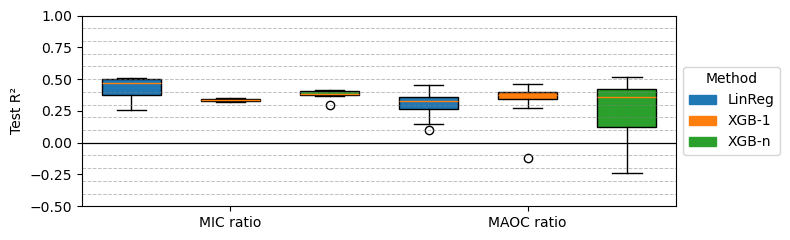

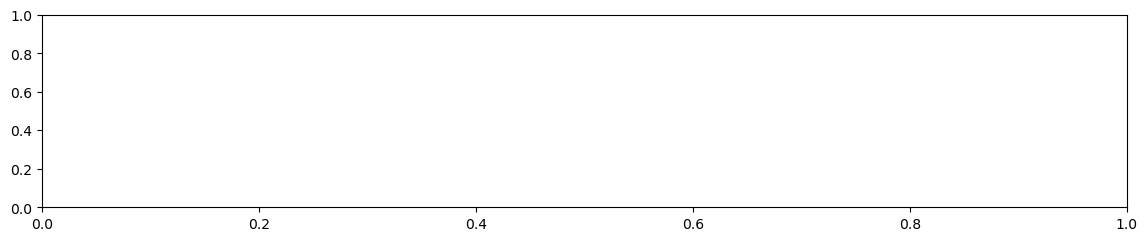

In [40]:
# load 5_with_predictions.pkl -> boxplots, transferability plots
import pickle
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from config import TARGET_CONFIG, TRAIN_DEFAULTS

# Load the predictions DataFrame from '5_with_predictions.pkl'
with open('1_preprocessed.pkl', 'rb') as f:
    pred_df = pickle.load(f)

def boxplot(plot_vars):
    # x tick labels mapping: MIC => "MIC ratio", MAOC => "MAOC ratio"
    xtick_labels = []
    for var in plot_vars:
        if var == 'MIC':
            xtick_labels.append("MIC ratio")
        elif var == 'MAOC':
            xtick_labels.append("MAOC ratio")
        else:
            xtick_labels.append(var)

    fig, ax = plt.subplots(figsize=(len(plot_vars)*3+2, 2.5))
    for var in plot_vars:
        for method in TRAIN_DEFAULTS['models']:
            cols = [f'pred_{var}_fold{f}_{method}' for f in range(10)]
            mask = (pred_df['split'] == 'test') & (~pred_df[TARGET_CONFIG[var]['target_name']].isna())
            preds = pred_df.loc[mask, cols]
            target = pred_df.loc[mask, TARGET_CONFIG[var]['target_name']]
            r2s = [r2_score(target, preds[col]) for col in cols]
            ax.boxplot(
                r2s,
                positions=[plot_vars.index(var)*len(TRAIN_DEFAULTS['models']) + TRAIN_DEFAULTS['models'].index(method)],
                widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor='C{}'.format(TRAIN_DEFAULTS['models'].index(method))))

    ax.set_xticks([i * len(TRAIN_DEFAULTS['models']) + len(TRAIN_DEFAULTS['models'])/2 - 0.5 for i in range(len(plot_vars))])
    ax.set_xticklabels(xtick_labels)
    ax.set_ylim(-0.5, 1)
    ax.set_ylabel('Test R²')

    y = -0.5
    while y <= 1.001:
        if abs(y - 0.0) < 1e-8:
            ax.axhline(y=0.0, color='black', linestyle='-', linewidth=0.9, alpha=1.0)
        else:
            ax.axhline(y=y, color='gray', linestyle='dashed', linewidth=0.7, alpha=0.5)
        y = round(y + 0.1, 10)

    method_colors = [f'C{i}' for i in range(len(TRAIN_DEFAULTS['models']))]
    handles = [mpatches.Patch(color=method_colors[i], label=method) for i, method in enumerate(TRAIN_DEFAULTS['models'])]
    ax.legend(handles=handles, title='Method', loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
    plt.tight_layout()
    plt.savefig(f'figures/boxplot_{"_".join(plot_vars)}.png', dpi=150)

boxplot(['MIC', 'MAOC'])
boxplot(['SOC09', 'SOC15', 'SOC18', 'dSOC_09_18'])

Predict 2015 SOC with 2018 model

In [ ]:
# Save the figure produced in addition to showing it
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

results = pd.read_pickle("1_preprocessed.pkl")
results.columns.values
OC_15_pred_with_15_model = results["pred_SOC15_median_XGB_inf_OC_2015"]
OC_15_pred_with_09_model = results["pred_SOC09_median_XGB_inf_OC_2015"]
OC_15_pred_with_18_model = results["pred_SOC18_median_XGB_inf_OC_2015"]

def plot_oc_compare_hexbin(
    OC_15_pred_with_15_model, OC_15_pred_with_09_model, OC_15_pred_with_18_model, 
    max_lim=None, save_name_suffix=""
):
    import matplotlib.pyplot as plt
    import numpy as np

    # Optionally filter points to be inside [0, max_lim] for both x and y in each subplot
    x1, y1 = OC_15_pred_with_15_model, OC_15_pred_with_09_model
    x2, y2 = OC_15_pred_with_15_model, OC_15_pred_with_18_model
    if max_lim is not None:
        mask1 = (x1 >= 0) & (x1 <= max_lim) & (y1 >= 0) & (y1 <= max_lim)
        mask2 = (x2 >= 0) & (x2 <= max_lim) & (y2 >= 0) & (y2 <= max_lim)
        x1, y1 = x1[mask1], y1[mask1]
        x2, y2 = x2[mask2], y2[mask2]
        lims_15_09 = [0, max_lim]
        lims_15_18 = [0, max_lim]
    else:
        lims_15_09 = [
            min(OC_15_pred_with_15_model.min(), OC_15_pred_with_09_model.min()),
            max(OC_15_pred_with_15_model.max(), OC_15_pred_with_09_model.max()),
        ]
        lims_15_18 = [
            min(OC_15_pred_with_15_model.min(), OC_15_pred_with_18_model.min()),
            max(OC_15_pred_with_15_model.max(), OC_15_pred_with_18_model.max()),
        ]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Hexbin 1: 2015 model vs 2009 model
    hb1 = axs[0].hexbin(
        x1, y1, gridsize=50, cmap="viridis", mincnt=1
    )
    axs[0].plot(lims_15_09, lims_15_09, "r--", lw=1)
    axs[0].set_xlim(lims_15_09)
    axs[0].set_ylim(lims_15_09)
    axs[0].set_aspect("equal", "box")
    axs[0].set_xlabel("OC_2015 predicted by 2015 model")
    axs[0].set_ylabel("OC_2015 predicted by 2009 model")
    cb1 = fig.colorbar(hb1, ax=axs[0], label='N points')

    # Hexbin 2: 2015 model vs 2018 model
    hb2 = axs[1].hexbin(
        x2, y2, gridsize=50, cmap="viridis", mincnt=1
    )
    axs[1].plot(lims_15_18, lims_15_18, "r--", lw=1)
    axs[1].set_xlim(lims_15_18)
    axs[1].set_ylim(lims_15_18)
    axs[1].set_aspect("equal", "box")
    axs[1].set_xlabel("OC_2015 predicted by 2015 model")
    axs[1].set_ylabel("OC_2015 predicted by 2018 model")
    cb2 = fig.colorbar(hb2, ax=axs[1], label='N points')

    plt.tight_layout()
    save_name = "figures/oc_compare_hexbin"
    if save_name_suffix:
        save_name += f"_{save_name_suffix}"
    save_name += ".png"
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

# Plot without fixed max limit (default behavior, like before)
plot_oc_compare_hexbin(OC_15_pred_with_15_model, OC_15_pred_with_09_model, OC_15_pred_with_18_model)

# Plot with fixed max limit of 100 for both axes
plot_oc_compare_hexbin(
    OC_15_pred_with_15_model,
    OC_15_pred_with_09_model,
    OC_15_pred_with_18_model,
    max_lim=100,
    save_name_suffix="max100"
)

Parameter ranges

In [ ]:
from config import default_param_ranges, default_state_bounds

import pandas as pd

translate = {
    "Cp": "POC",
    "Cb": "MIC",
    "Cm": "MAOC"
}

# Make table for default_param_ranges
param_rows = []
for p, vals in default_param_ranges.items():
    row = {
        "Parameter/State variable": p,
        "Description": vals["description"],
        "Min": vals["min"],
        "Craig's Default": vals["default"],
        "Max": vals["max"],
        "Unit": vals["unit"]
    }
    param_rows.append(row)
df_params = pd.DataFrame(param_rows)

# Make table for default_state_bounds
state_rows = []
for s, vals in default_state_bounds.items():
    row = {
        "Parameter/State variable": translate[s],
        "Description": vals["description"],
        "Min": vals["min"],
        "Craig's Default": vals["default"],
        "Max": vals["max"],
        "Unit": vals.get("unit", "")
    }
    state_rows.append(row)
df_states = pd.DataFrame(state_rows)

df_all = pd.concat([df_params, df_states], ignore_index=True)
print("Default Parameter Ranges and State Bounds (concatenated):")
display(df_all)
df_all.to_csv("figures/default_param_ranges_and_state_bounds.csv", index=False)

Sensitivity Analysis

In [ ]:
import jax
import jax.numpy as jnp
from itertools import product
import diffrax as dfx
import numpy as np
import pandas as pd

from config import default_param_ranges, default_state_bounds
from models import craig_BA_adapt, analytical_steady_state

# get ranges
state_names = list(default_state_bounds.keys())
state_mins = jnp.array([default_state_bounds[name]["min"] for name in state_names])
state_maxs = jnp.array([default_state_bounds[name]["max"] for name in state_names])
state_diffs = state_maxs - state_mins  # difference between max and min for state variables
SOC_diff = jnp.sum(state_diffs)
param_names = list(default_param_ranges.keys())
param_mins = jnp.array([default_param_ranges[name]["min"] for name in param_names])
param_maxs = jnp.array([default_param_ranges[name]["max"] for name in param_names])
param_diffs = param_maxs - param_mins  # difference between max and min for parameters
# create random initial conditions and params
key_params, key_states = jax.random.split(jax.random.PRNGKey(0), 2)
n_samples = 1000000
random_params = jax.random.uniform(key_params, shape=(n_samples, len(param_names))) # 0-1
random_states = jax.random.uniform(key_states, shape=(n_samples, len(state_names))) # 0-1
random_params = param_mins + (param_maxs - param_mins) * random_params # scaled right
random_states = state_mins + (state_maxs - state_mins) * random_states # scaled right
# loop over versions & over temps
results = []
for dec, tur, sat, mode in product(
        ["linear", "MM", "RMM"],
        ["linear", "density_dependent"],
        ["no", "Langmuir"],
        ["steady", "dynamic"]):
    version = dict(microbial_decomposition=dec,microbial_turnover=tur,saturation=sat,) # get model
    p_senss = np.full((n_samples, len(param_names)), jnp.nan)
    s_senss = np.full((n_samples, len(state_names)), jnp.nan)
    outputs = np.full((n_samples,), jnp.nan)
    if mode == "steady":
        def S_steady(param_set):
            return jnp.sum(analytical_steady_state(param_set, **version))
        outputs = jax.vmap(S_steady)(random_params)
        p_senss =  jax.vmap(jax.grad(S_steady))(random_params)
        s_senss = np.full((n_samples, len(state_names)), jnp.nan)  # no state sensitivity in steady
    elif mode == "dynamic":
        solver, saveat = dfx.Euler(), dfx.SaveAt(t0=False, t1=True)
        def rhs(t, y, args): 
            return craig_BA_adapt(t, y, args, **version)
        def delta_S_dynamic(p, y0):
            sol = dfx.diffeqsolve(dfx.ODETerm(rhs),solver,
                                  t0=0.0, t1=9.0, dt0=0.05,
                                  y0=y0, args=p, saveat=saveat)
            yT = sol.ys[-1]
            return jnp.sum(yT) - jnp.sum(y0)
        grad_delta_S_dynamic = jax.vmap(lambda p, y0: jax.grad(delta_S_dynamic, argnums=(0,1))(p, y0),in_axes=(0, 0))
        delta_S_dynamic_vmap = jax.vmap(delta_S_dynamic, in_axes=(0, 0))
        outputs = delta_S_dynamic_vmap(random_params, random_states)
        p_senss, s_senss = grad_delta_S_dynamic(random_params, random_states)
    print(f"[{mode}] md={dec} mt={tur} sat={sat} -- completed")
    p_senss = np.abs(p_senss) # so importance doesn't cancel out
    s_senss = np.abs(s_senss) # so importance doesn't cancel out
    p_senss = p_senss * param_diffs / SOC_diff # normalize
    s_senss = s_senss * state_diffs / SOC_diff # normalize
    p_senss_median = np.nanmedian(p_senss, axis=0) # get median
    s_senss_median = np.nanmedian(s_senss, axis=0) # get median
    results.append(dict(md=dec, mt=tur, sat=sat, temp=mode,
             **dict(zip(param_names, p_senss_median)),
             **{f"y0_{s}": v for s, v in zip(state_names, s_senss_median)}))
df_results = pd.DataFrame(results)
df_results = df_results.round(5)
df_results.to_csv("figures/sensitivities.csv", index=False)
print(df_results)